# Audio Deepfake Detection - Project Report

**A systematic comparison of deep-learning architectures for real-vs-fake speech detection, emphasising cross-dataset generalisation and per-class behaviour under class imbalance.**

Deep Learning course project. All models are **trained and validated on Fake-or-Real (FoR)** (in-domain) and **tested on In-the-Wild (ITW)** (cross-dataset), so every headline number measures generalisation to an unseen domain rather than in-distribution fit.

---

## Summary

| Finding | Evidence |
|---|---|
| **Representation learning drives generalisation.** Cross-dataset AUC rises monotonically as more of the pipeline is learned. | MLP 0.79 -> CNN/CRNN 0.86-0.87 -> WavLM probe 0.92 (ITW AUC) |
| **AUC measures ranking quality; low fake-recall at threshold 0.5 is a calibration problem, not a modelling failure.** High AUC is necessary but not sufficient — the default threshold may need tuning under class imbalance and domain shift. | Fake-class **recall** at threshold 0.5: MLP 0.17, RNN 0.17, WavLM ft 0.45, CRNN 0.54, WavLM probe 0.57, CNN 0.72 |
| **Convolution carries the recurrent path.** A pure BiLSTM is weak; CNN blocks recover nearly all the CNN performance. | RNN AUC 0.66 vs CRNN 0.86 |
| **Under domain shift, freezing the backbone beats fine-tuning.** | FoR AUC up to 0.99 while ITW AUC down to ~0.86; frozen probe ITW AUC 0.92 |

---

## 1. Objective

Binary classification of speech as **real (bonafide)** vs **fake (spoofed / synthetic)**. Instead of fine-tuning one pretrained model, the project compares four families that differ in how much of the pipeline is learned from data:


Families 1-3 get focused **one-axis ablations** (capacity, learning rate, regularisation). Family 4 is an analysis of *how* to use a pretrained backbone.

## 2. Methodology

### 2.1 Experimental design

The project is a **comparative study**. The four families are designed so that each step increases the fraction of the audio processing pipeline that is learned from data:

| # | Family | Input representation | What it tests |
|---|--------|----------------------|---------------|
| 1 | **MLP** | hand-crafted features (MFCC, chroma, spectral contrast, ZCR) | classical features + shallow classifier |
| 2 | **CNN** | mel-spectrogram | learned 2-D spectral features |
| 3 | **RNN / CRNN** | mel-spectrogram as a time series | temporal modelling (BiLSTM), with / without CNN blocks |
| 4 | **WavLM** | raw waveform | self-supervised transformer (`microsoft/wavlm-base-plus`) - frozen backbone with a linear 2-logit head vs full fine-tune |

### 2.2 Feature extraction

**MLP — 390-dimensional feature vector.** Extracted with Librosa at 16 kHz mono: 20 Mel-Frequency Cepstral Coefficients (frames of 256 samples, hop 128), 12-bin chroma, 7-band spectral contrast, and zero-crossing rate. Each feature is averaged across frames to produce a fixed-length per-clip vector. A `StandardScaler` is fit **exclusively on the training split** and reused unchanged at validation and test time to prevent leakage.

**CNN / RNN / CRNN — 128 × T log mel-spectrogram.** Computed with librosa: 128 mel bins, 1024-sample FFT window, 256-sample hop, at 16 kHz. Clips are trimmed or zero-padded to 8.5 s so all spectrograms share the same T dimension. The CNN treats this as a single-channel 2-D image; the RNN/CRNN treat it as a T-step sequence of 128-dimensional frame vectors.

**WavLM — raw waveform.** The [WavLMDataset](scripts\wavlm\wavlm_dataset.py) loads the audio file, using librosa, at 16kHz mono, applies z-score normalization, center-crops the files to a predefined amount of samples (80.000 in our case for 5s clips as defined in the [config file](training_configs\wavlm_base_plus.yaml)) or zero pads to the right up to that limit. Also an attention mask is created (**1** for **real** audio samples and **0** for **padding**) and all this is fed to `microsoft/wavlm-base-plus`.

### 2.3 Training protocol

All from-scratch models share the same training loop:
- **Loss:** Binary cross-entropy with sigmoid output; inference threshold fixed at 0.5.
- **Optimiser:** Adam; **LR scheduler:** `ReduceLROnPlateau` (factor 0.5, patience 3 on validation loss).
- **Early stopping:** patience 5 epochs on validation loss; the best-epoch checkpoint is used at test time.
- **Batch size:** 64; **max epochs:** 30; **seed:** 42 (fixed globally for reproducibility).
- **Augmentation:** none for families 1–3.

**WavLM Base Plus** WavLM Base Plus is a self-supervised speech 94.7M parameter transformer model from Microsoft, pretrained on 94k hours of unlabeled English audio producing general-purpose frame-level representations of raw 16 kHz waveforms. Both approaches we followed utilize the same linear head on the model's backbone and they differ only in what is trained.

- **Representation (shared):**
  - Εach of WavLM's **12 transformer layers** produces frame-level features, mean-pooled over time (ignoring padded frames) resulting to one 768-d vector per layer.
  - A learnable softmax over the transformer layers combines them into a single weighted-sum embedding (the CNN-embedding output is excluded). The learned weights also reveal information on the importance of each layer.
  - Either a **linear layer** maps the 768-d embedding to the real/fake logits.
  - Or an MLP consisting of the following layers: Linear(768 → 256), BatchNorm1d(256), GELU, Dropout(0.5), Linear(256 → 2)

- **Frozen backbone:** the backbone is frozen and its hidden states are extracted once and cached per split. Only the **12 softmax layer-weights + the linear / MLP head** are trained. Cross-entropy loss, Adam, lr 1e-3, 20 epochs, batch 32, 5 s clips.

- **Full fine-tuning:** the backbone is also trainable.
  - **Optimiser & schedule:** AdamW with **discriminative learning rates** (backbone 1e-5, head 1e-3), with weight decay of 1e-2
  - **Compute:** Lowered to 4s clips due to memory constraints, batch size 32, up to 50 epochs with early-stopping patience of 5 epochs on the validation loss
  - **Configurations explored**: We performed exploratory runs and not a full grid of parameters due to lack compute and time constraints. We mainly focused on the number of unfrozen **top transformer layers** (2, 4, 6, or a full unfreeze were the CNN feature encoder stays frozen except in the full-unfreeze runs), **batch size** (32 vs 64), and **augmentation** (noise + reverb, with or without codec, or none);
  - **Augmentation:** MUSAN additive noise (0–15 dB), simulated-RIR reverberation, and optional codec compression — applied to the **training split only**.

## 3. Datasets & evaluation protocol

| Split | Dataset | Role |
|-------|---------|------|
| Train + Validation | **Fake-or-Real (FoR)**, `for-norm` | in-domain fitting & model selection |
| Test | **In-the-Wild (ITW)**, trimmed + normalised | **cross-dataset** generalisation |

**Cross-dataset Evaluation**: Training on FoR and testing on the independently collected ITW set (31,779 clips - 19,963 real / 11,816 fake) gives an honest estimate, and the FoR->ITW gap is itself a key diagnostic.

**Class imbalance**: ITW is ~63% real / 37% fake. A model that simply chooses "real" can post a deceptively high accuracy while failing at the actual job (flagging fakes). We report 
per-class precision/recall/F1, and treat fake-class recall the fraction of spoofed clips actually detected as an important metric alongside AUC.

**Metrics**: AUC-ROC (threshold-free, primary), accuracy, per-class precision/recall/F1. EER is the conventional anti-spoofing headline; per-sample scores were not retained, so EER is future work.

## 4. Setup
The cells below load the **committed** experiment results under `results/` - this notebook presents them, it does not retrain. Run from the repository root.

In [5]:
import json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")

# --- shared visual style -------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 120,
    "font.size": 10.5,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelcolor": "#22303a",
    "axes.edgecolor": "#9aa7b0",
    "axes.linewidth": 0.9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#c9d3da",
    "grid.alpha": 0.5,
    "grid.linewidth": 0.7,
    "xtick.color": "#42505a",
    "ytick.color": "#42505a",
    "text.color": "#22303a",
})
# cohesive palette (teal / blue / amber / coral / violet / slate)
PAL = {"teal": "#0E9594", "blue": "#3E7CB1", "amber": "#E9B949",
       "coral": "#E8674F", "violet": "#8E7CC3", "slate": "#5C6B73",
       "ink": "#22303a", "mute": "#cfd8dd"}

ROOT = Path.cwd()
RESULTS = ROOT / "results"

def load_summary(rel):
    return pd.read_csv(RESULTS / rel).sort_values("auc", ascending=False).reset_index(drop=True)

FAM = {"MLP": "nn_experiments/simple_nn", "CNN": "cnn_experiments/cnn",
       "CRNN": "crnn_experiments/crnn", "RNN": "rnn_experiments/rnn"}
summ = {k: load_summary(f"{v}/comparison/metrics_summary.csv") for k, v in FAM.items()}
print("Runs per family:", {k: len(v) for k, v in summ.items()})

def _parse_clf(p):
    t = Path(p).read_text(); out = {}
    for cls in ("Real", "Fake"):
        m = re.search(cls + r"\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+(\d+)", t)
        out[cls] = tuple(float(x) for x in m.groups()[:3])
    return out

def family_metrics(fam, sub):
    rows = []
    for _, r in summ[fam].iterrows():
        tag = r["tag"]
        rep = _parse_clf(RESULTS / sub / "experiments" / tag / "checkpoints" / ("metrics_" + tag + ".txt"))
        Rf, (Fp, Fr, Ff) = rep["Real"][2], rep["Fake"]
        rows.append({"tag": tag, "AUC": r["auc"], "accuracy": r["test_acc"],
                     "macro_F1": (Rf + Ff) / 2, "fake_recall": Fr})
    return pd.DataFrame(rows)

_ABBR = {"depth": "depth", "base_channels": "ch", "lr": "lr", "dropout": "do",
         "weight_decay": "wd", "cnn_depth": "cd", "num_rnn_layers": "rl",
         "rnn_hidden": "rh", "num_layers": "L", "hidden_size": "h", "hidden_sizes": "h"}

def _fmt(v):
    if isinstance(v, (int, np.integer)):
        return str(int(v))
    if isinstance(v, (float, np.floating)):
        return f"{v:.0e}".replace("e-0", "e-").replace("e+0", "e") if (v != 0 and abs(v) < 1e-2) else f"{v:g}"
    return str(v)

def plot_family(fam, sub):
    # labels built from the ACTUAL hyperparameter values (same as the table), not the tag
    d = family_table(fam, sub).iloc[::-1].reset_index(drop=True)   # ascending AUC for barh
    cols = CONFIG_COLS[fam]
    labels = [", ".join(f"{_ABBR.get(c, c)}={_fmt(r[c])}" for c in cols) for _, r in d.iterrows()]
    y = np.arange(len(d)); h = 0.2
    mets = [("AUC", "AUC", PAL["teal"]), ("accuracy", "accuracy", PAL["blue"]),
            ("macro_F1", "macro-F1", PAL["amber"]), ("fake_R", "fake recall", PAL["coral"])]
    plt.figure(figsize=(10, 0.6 * len(d) + 1.8))
    for i, (col, lab, c) in enumerate(mets):
        off = (1.5 - i) * h
        plt.barh(y + off, d[col], h, label=lab, color=c, edgecolor="white", linewidth=0.4)
    plt.yticks(y, labels, fontsize=7.5); plt.xlim(0, 1.0); plt.xlabel("score")
    plt.title(f"{fam}: performance metrics across configurations")
    plt.legend(loc="lower right", ncol=2, fontsize=8, framealpha=0.9)
    plt.tight_layout(); plt.show()

CONFIG_COLS = {
    "MLP":  ["hidden_sizes", "lr", "dropout", "weight_decay"],
    "CNN":  ["depth", "base_channels", "lr", "dropout", "weight_decay"],
    "CRNN": ["cnn_depth", "base_channels", "num_rnn_layers", "rnn_hidden", "lr", "dropout", "weight_decay"],
    "RNN":  ["num_layers", "hidden_size", "lr", "dropout", "weight_decay"],
}

def family_table(fam, sub):
    # per-configuration table: actual hyperparameter values + saved per-class metrics
    rows = []
    for _, r in summ[fam].iterrows():
        tag = r["tag"]
        rep = _parse_clf(RESULTS / sub / "experiments" / tag / "checkpoints" / ("metrics_" + tag + ".txt"))
        (Rp, Rr, Rf), (Fp, Fr, Ff) = rep["Real"], rep["Fake"]
        row = {c: r[c] for c in CONFIG_COLS[fam]}
        row.update({"AUC": r["auc"], "accuracy": r["test_acc"], "macro_F1": (Rf + Ff) / 2,
                    "real_P": Rp, "real_R": Rr, "real_F1": Rf,
                    "fake_P": Fp, "fake_R": Fr, "fake_F1": Ff})
        rows.append(row)
    return pd.DataFrame(rows).sort_values("AUC", ascending=False).reset_index(drop=True)

def _sortkey(v):
    try:
        return (0, float(v), 0)
    except (TypeError, ValueError):
        nums = [int(x) for x in re.findall(r"\d+", str(v))]
        return (1, len(nums), nums[0] if nums else 0)

def plot_hparam_effects(fam, sub, metrics=("AUC", "accuracy", "macro_F1")):
    # controlled one-axis view: vary ONE hyperparameter, hold the others at the baseline
    import math
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    
    d = family_table(fam, sub)
    cols = CONFIG_COLS[fam]
    base = {c: d[c].mode().iloc[0] for c in cols}          # baseline = most common value per axis
    mc = {"AUC": PAL["teal"], "accuracy": PAL["blue"], "macro_F1": PAL["amber"], "fake_R": PAL["coral"]}
    specs = []
    
    for h in cols:
        others = [c for c in cols if c != h]
        if others:
            mask = (d[others] == pd.Series({c: base[c] for c in others})).all(axis=1)
            sd = d[mask]
        else:
            sd = d
        if sd[h].nunique() >= 2:
            specs.append((h, sd))
            
    n = len(specs); ncol = min(3, n); nrow = math.ceil(n / ncol)
    fig, axs = plt.subplots(nrow, ncol, figsize=(4.3 * ncol, 3.2 * nrow), squeeze=False)
    
    for ax in axs.flat:
        ax.set_visible(False)
        
    for k, (h, sd) in enumerate(specs):
        ax = axs[k // ncol][k % ncol]; ax.set_visible(True)
        sd = sd.assign(_sk=sd[h].map(_sortkey)).sort_values("_sk")
        xpos = np.arange(len(sd)); xlab = [_fmt(v) for v in sd[h]]
        
        for met in metrics:
            ax.plot(xpos, sd[met], marker="o", ms=5, lw=2, color=mc.get(met), label=met.replace("_", "-"))
            
        bi = [i for i, v in enumerate(sd[h]) if _fmt(v) == _fmt(base[h])]
        if bi:
            ax.axvline(bi[0], color=PAL["slate"], ls=":", lw=1.1, alpha=0.75)
            ax.text(bi[0], 0.47, "baseline", rotation=90, fontsize=7, color=PAL["slate"], va="bottom", ha="right")
            
        # Tilted x-axis labels
        ax.set_xticks(xpos)
        ax.set_xticklabels(xlab, fontsize=8, rotation=45, ha="right")
        
        ax.set_title(_ABBR.get(h, h), fontsize=10, fontweight="bold")
        ax.set_ylim(0.45, 1.0); ax.grid(alpha=0.3); ax.set_xlabel(h, fontsize=8)

    handles, labels = ax.get_legend_handles_labels()
    
    # loc="upper center" and bbox_to_anchor center it. 
    # ncol=len(labels) forces the legend to be a single horizontal row.
    fig.legend(handles, labels, fontsize=9, loc="upper center", 
               bbox_to_anchor=(0.5, 0.94), ncol=len(labels))

    # Placed the title slightly higher so it sits above the new legend
    fig.suptitle(f"{fam}: effect of each hyperparameter (others held at baseline)", 
                 fontweight="bold", y=0.98)
    
    # The 'rect' argument [left, bottom, right, top] restricts the subplots 
    # to the bottom 88% of the figure, leaving the top 12% empty for the title and legend.
    fig.tight_layout(rect=[0, 0, 1, 0.88]) 
    
    plt.show()

Runs per family: {'MLP': 10, 'CNN': 10, 'CRNN': 10, 'RNN': 10}


In [2]:
def style_table(df):
    """Apply red→green gradient to AUC, fake_R, and fake_F1 columns only (fixed scale 0.5–1.0)."""
    cols = [c for c in ["AUC", "ITW_AUC", "ITW_fake_recall", "ITW_fake_F1", "fake_R", "fake_F1"]
            if c in df.columns]
    return df.style.background_gradient(subset=cols, cmap="RdYlGn", vmin=0.5, vmax=1.0)

## 5. Architecture 1 - MLP on hand-crafted features
A shallow fully-connected network over classical descriptors (MFCC, chroma, spectral contrast, ZCR) aggregated per clip. No representation learning - the baseline.

**Experimental Parameters:** hidden width / depth, learning rate, dropout, weight decay.

In [3]:
style_table(family_table("MLP", "nn_experiments/simple_nn"))

,hidden_sizes,lr,dropout,weight_decay,AUC,accuracy,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,"[256, 128, 64]",0.001000,0.500000,0.000100,0.786364,0.683150,0.543600,0.666700,0.987300,0.796000,0.891400,0.174000,0.291200
1,"[256, 128, 64]",0.000500,0.500000,0.000100,0.769415,0.662945,0.498900,0.652700,0.986500,0.785600,0.843300,0.121400,0.212200
2,[128],0.000500,0.500000,0.000100,0.759952,0.662977,0.494800,0.651900,0.990400,0.786300,0.877100,0.115000,0.203300
3,"[256, 128, 64, 32]",0.000500,0.500000,0.000100,0.758755,0.668750,0.514700,0.657200,0.984100,0.788100,0.841400,0.140900,0.241300
4,"[256, 128]",0.000500,0.500000,0.000100,0.749350,0.668781,0.512600,0.656800,0.986300,0.788500,0.857100,0.137300,0.236700
5,"[256, 128, 64]",0.000500,0.500000,0.001000,0.748810,0.672461,0.523050,0.659800,0.984200,0.790000,0.850600,0.150700,0.256100
6,"[512, 256, 128, 64]",0.000500,0.500000,0.000100,0.741641,0.663643,0.498650,0.652800,0.988300,0.786300,0.859900,0.120300,0.211000
7,"[256, 128, 64]",0.000500,0.300000,0.000100,0.731605,0.666656,0.508600,0.655500,0.985500,0.787300,0.845400,0.133100,0.229900
8,"[256, 128, 64]",0.000100,0.500000,0.000100,0.730407,0.651970,0.478150,0.646100,0.981700,0.779300,0.765700,0.100100,0.177000
9,"[512, 256, 128]",0.000500,0.500000,0.000100,0.694120,0.658663,0.490800,0.650100,0.984700,0.783200,0.815200,0.113000,0.198400


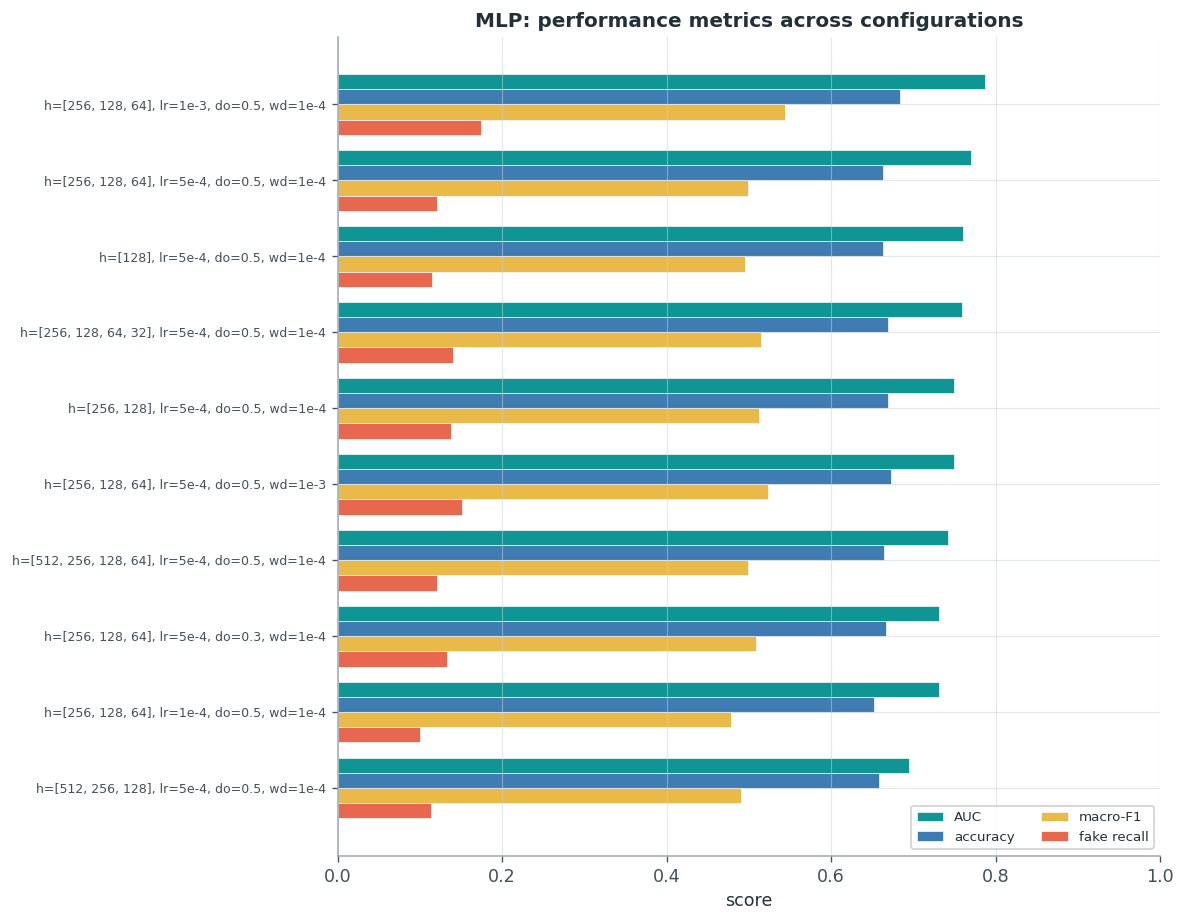

In [4]:
plot_family("MLP", "nn_experiments/simple_nn")

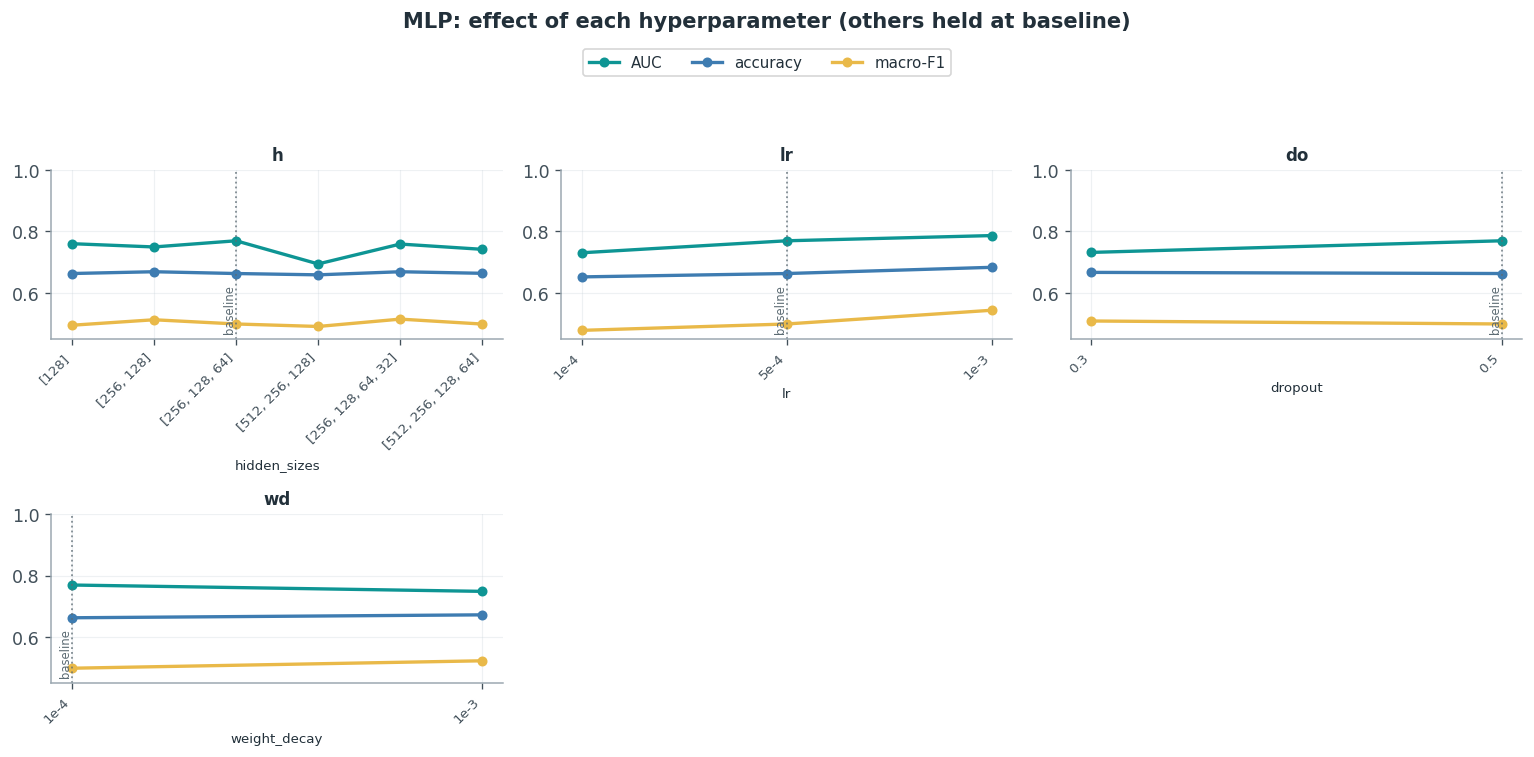

In [5]:
plot_hparam_effects("MLP", "nn_experiments/simple_nn")

**Interpretation.** Caps at **AUC ~ 0.79 / acc ~ 0.68** - above chance but the weakest learned model.

- **Capacity** The widest nets (`512-256-128(-64)`) do *worse*: they overfit FoR-specific structure and transfer less well. Best is a modest `256-128-64`.
- **Learning rate** `1e-3` clearly beats `5e-4`/`1e-4`, the small feature space is easy to optimise, so a larger step converges to a better solution faster.

The ceiling is set by the features, not the classifier: hand-crafted descriptors discard the fine spectro-temporal detail that exposes modern synthesis artefacts.

## 6. Architecture 2 - CNN on mel-spectrograms
A 2-D CNN over the mel-spectrogram, learning local spectro-temporal filters end-to-end.

**Experimental Parameters:** conv depth, base channels, learning rate, dropout, weight decay.

In [6]:
style_table(family_table("CNN", "cnn_experiments/cnn"))

,depth,base_channels,lr,dropout,weight_decay,AUC,accuracy,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,3,32,0.001000,0.500000,0.000100,0.870214,0.826584,0.810250,0.841800,0.891400,0.865900,0.796300,0.717000,0.754600
1,3,64,0.000500,0.500000,0.000100,0.863989,0.814563,0.785600,0.799400,0.940800,0.864400,0.857500,0.601200,0.706800
2,4,32,0.000500,0.500000,0.000100,0.837683,0.777841,0.736350,0.764100,0.935000,0.841000,0.823400,0.512400,0.631700
3,3,32,0.000500,0.300000,0.000100,0.771223,0.741118,0.688500,0.735900,0.916900,0.816500,0.759900,0.444100,0.560500
4,3,16,0.000500,0.500000,0.000100,0.709133,0.660531,0.646950,0.754300,0.681700,0.716100,0.537400,0.624800,0.577800
5,3,32,0.000500,0.500000,0.000100,0.681366,0.670317,0.630250,0.712900,0.795600,0.752000,0.570500,0.458600,0.508500
6,3,32,0.000500,0.500000,0.000010,0.670497,0.655622,0.624650,0.715300,0.750500,0.732500,0.540200,0.495300,0.516800
7,3,32,0.000500,0.500000,0.001000,0.564437,0.525158,0.522300,0.670700,0.479600,0.559300,0.406500,0.602100,0.485300
8,2,32,0.000500,0.500000,0.000100,0.548361,0.528808,0.521600,0.658800,0.518400,0.580200,0.401700,0.546400,0.463000
9,3,32,0.000100,0.500000,0.000100,0.547870,0.519777,0.515450,0.658800,0.488600,0.561000,0.398500,0.572500,0.469900


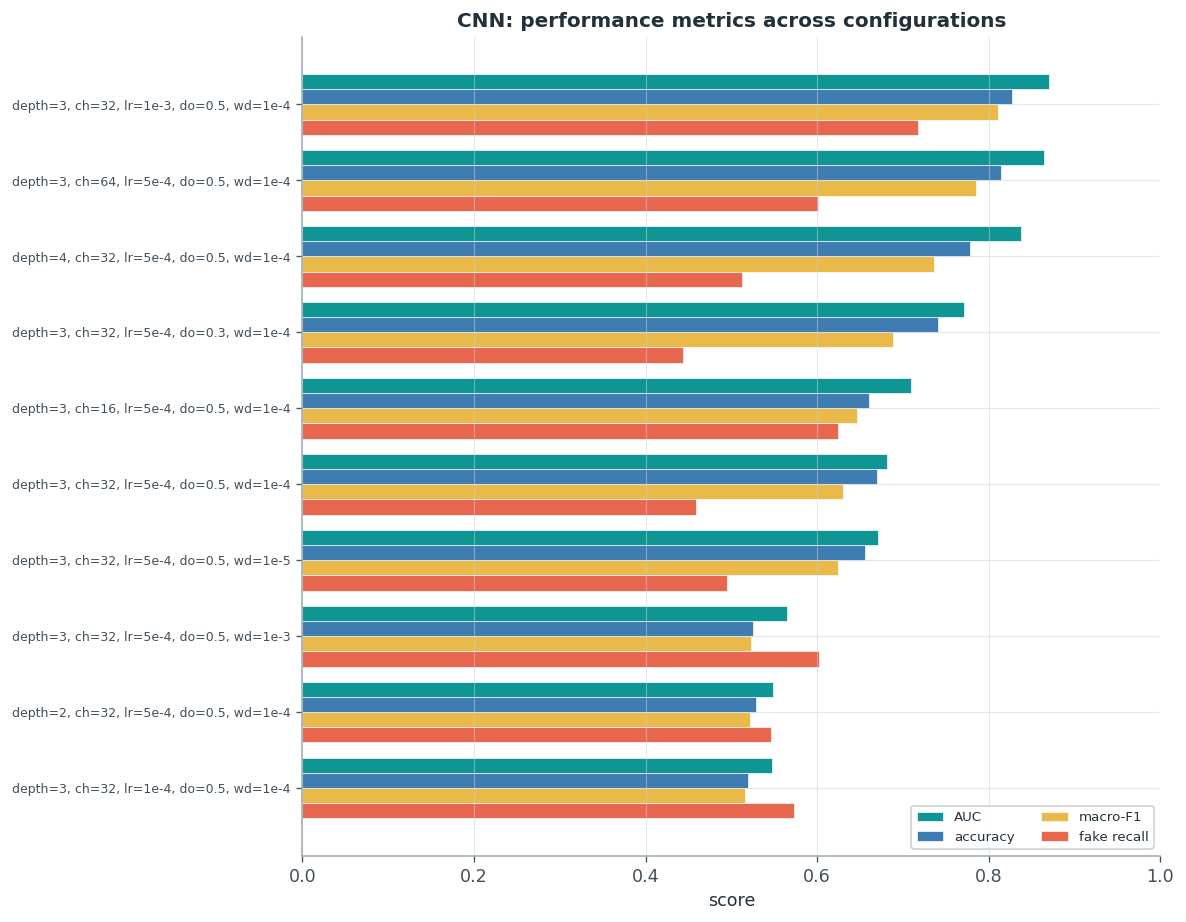

In [7]:
plot_family("CNN", "cnn_experiments/cnn")

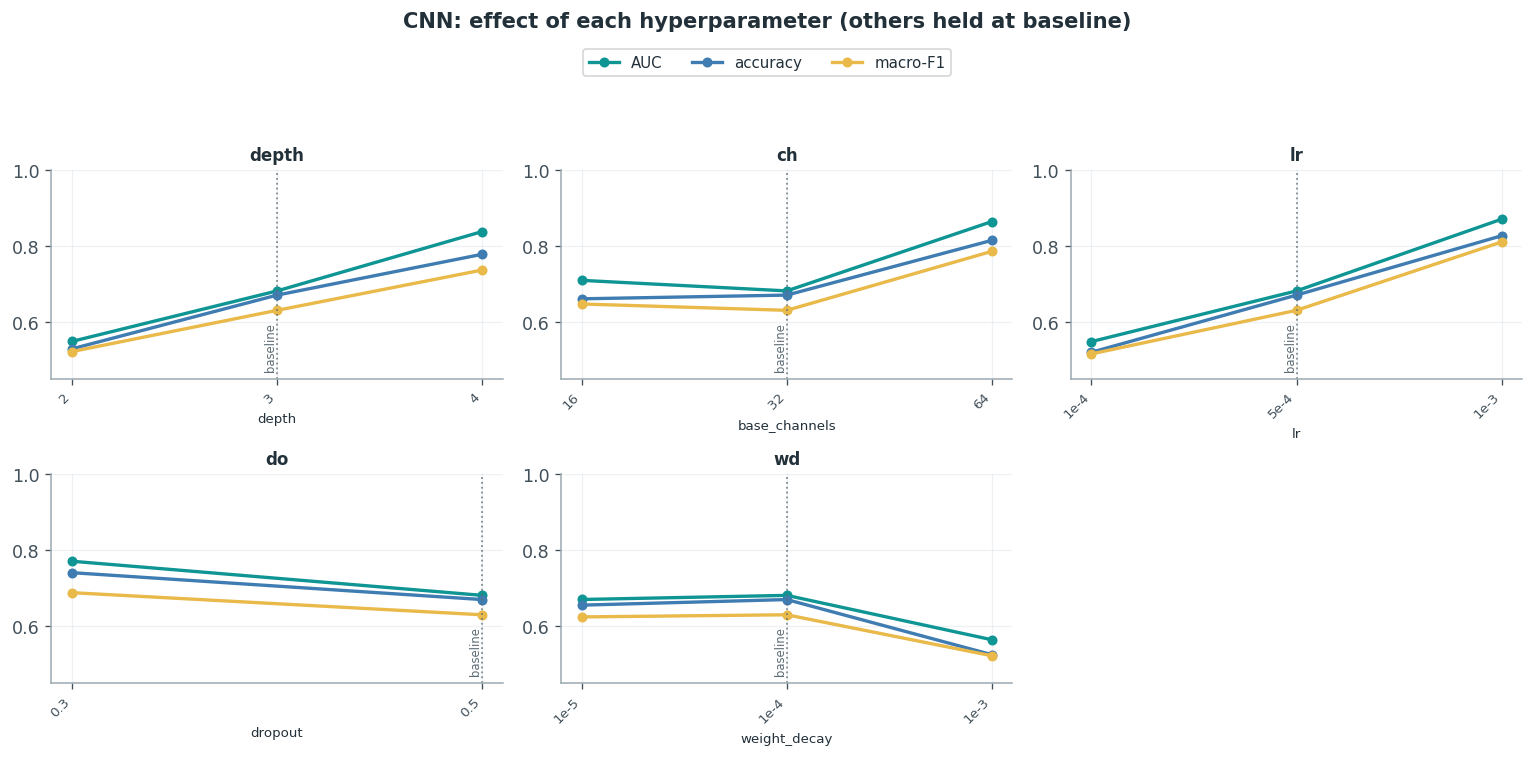

In [8]:
plot_hparam_effects("CNN", "cnn_experiments/cnn")

**Interpretation:** The **strongest non-pretrained model: AUC ~ 0.87 / acc ~ 0.83**, and the best fake-recall of any model here.

- **Depth has a sweet spot:** 3 conv blocks is best; 4 hurts, 2 collapses (AUC 0.55).
- **Enough width is necessary:** 16 channels underperforms, 32 is the sweet spot, 64 adds nothing.
- **Regularisation:** Weight decay `1e-3` is catastrophic (AUC 0.56); `1e-4` is right. Dropout 0.5 > 0.3.
- **Best**: depth 3, ch 32, lr 1e-3, dropout 0.5, wd 1e-4.

## 7. Architecture 3 - Recurrent models (RNN & CRNN)
Two similar model variants on the same mel input: a pure **BiLSTM (RNN)** over frame vectors, and a **CRNN** with a CNN block before the BiLSTM.

**Experimental Parameters:** recurrent layers, hidden size, (CRNN) conv depth/channels, learning rate, dropout.

In [9]:
print("=== CRNN ==="); display(style_table(family_table("CRNN", "crnn_experiments/crnn")))
print("\n=== RNN (pure BiLSTM) ==="); display(style_table(family_table("RNN", "rnn_experiments/rnn")))

=== CRNN ===


,cnn_depth,base_channels,num_rnn_layers,rnn_hidden,lr,dropout,weight_decay,AUC,accuracy,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,3,32,2,128,0.000500,0.500000,0.000100,0.859611,0.805375,0.766700,0.778300,0.965100,0.861700,0.900800,0.535500,0.671700
1,4,32,2,128,0.000500,0.500000,0.000100,0.838841,0.789924,0.768800,0.810100,0.869300,0.838700,0.748100,0.655800,0.698900
2,3,32,3,128,0.000500,0.500000,0.000100,0.831320,0.754146,0.707400,0.747800,0.918400,0.824400,0.775700,0.476600,0.590400
3,3,32,2,128,0.000500,0.300000,0.000100,0.754871,0.735423,0.693950,0.745700,0.878400,0.806600,0.706200,0.493900,0.581300
4,3,16,2,128,0.000500,0.500000,0.000100,0.744406,0.679096,0.553050,0.670200,0.963200,0.790400,0.762200,0.199100,0.315700
5,3,64,2,128,0.000500,0.500000,0.000100,0.732799,0.731301,0.697000,0.753800,0.849900,0.799000,0.676800,0.530900,0.595000
6,3,32,1,128,0.000500,0.500000,0.000100,0.720272,0.721986,0.689800,0.752300,0.831000,0.789700,0.653200,0.537800,0.589900
7,2,32,2,128,0.000500,0.500000,0.000100,0.604453,0.626420,0.585600,0.685700,0.748400,0.715700,0.497200,0.420300,0.455500
8,3,32,2,128,0.001000,0.500000,0.000100,0.556452,0.526920,0.519950,0.657500,0.515300,0.577800,0.400300,0.546500,0.462100
9,3,32,2,128,0.000100,0.500000,0.000100,0.548824,0.569401,0.541250,0.659500,0.650400,0.654900,0.422700,0.432500,0.427600



=== RNN (pure BiLSTM) ===


,num_layers,hidden_size,lr,dropout,weight_decay,AUC,accuracy,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,1,128,0.000500,0.500000,0.000100,0.659637,0.652443,0.519100,0.656200,0.938400,0.772300,0.619400,0.169300,0.265900
1,2,128,0.001000,0.500000,0.000100,0.649615,0.658580,0.553350,0.667300,0.910500,0.770100,0.606400,0.233000,0.336600
2,2,128,0.000500,0.300000,0.000100,0.633248,0.658328,0.542600,0.663800,0.924400,0.772700,0.620400,0.208900,0.312500
3,3,128,0.000500,0.500000,0.000100,0.623887,0.650492,0.515900,0.655000,0.937500,0.771200,0.610600,0.165600,0.260600
4,2,128,0.000100,0.500000,0.000100,0.592556,0.643633,0.562400,0.669300,0.855200,0.750900,0.539100,0.286100,0.373900
5,2,128,0.000500,0.500000,0.000100,0.591855,0.646465,0.490250,0.648400,0.955200,0.772400,0.622500,0.124900,0.208100
6,2,64,0.000500,0.500000,0.000100,0.580239,0.649769,0.506900,0.652700,0.945600,0.772300,0.620000,0.150000,0.241500
7,2,256,0.000500,0.500000,0.000100,0.571369,0.637906,0.522200,0.654000,0.899400,0.757300,0.535700,0.196100,0.287100
8,2,128,0.000500,0.500000,0.000010,0.568245,0.648699,0.516750,0.654800,0.932300,0.769300,0.597100,0.169600,0.264200
9,2,128,0.000500,0.500000,0.001000,0.487268,0.456559,0.456300,0.607500,0.381100,0.468400,0.358400,0.584000,0.444200


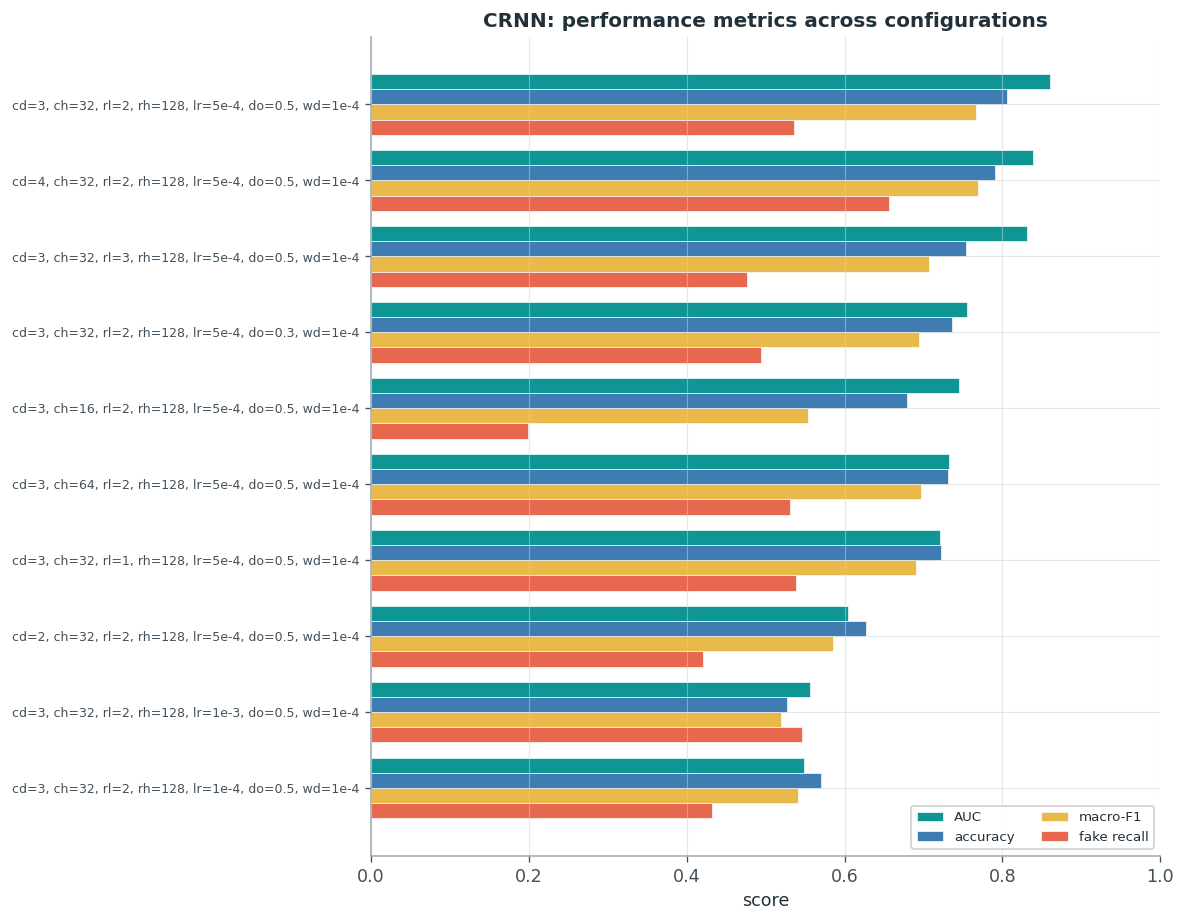

In [10]:
plot_family("CRNN", "crnn_experiments/crnn")

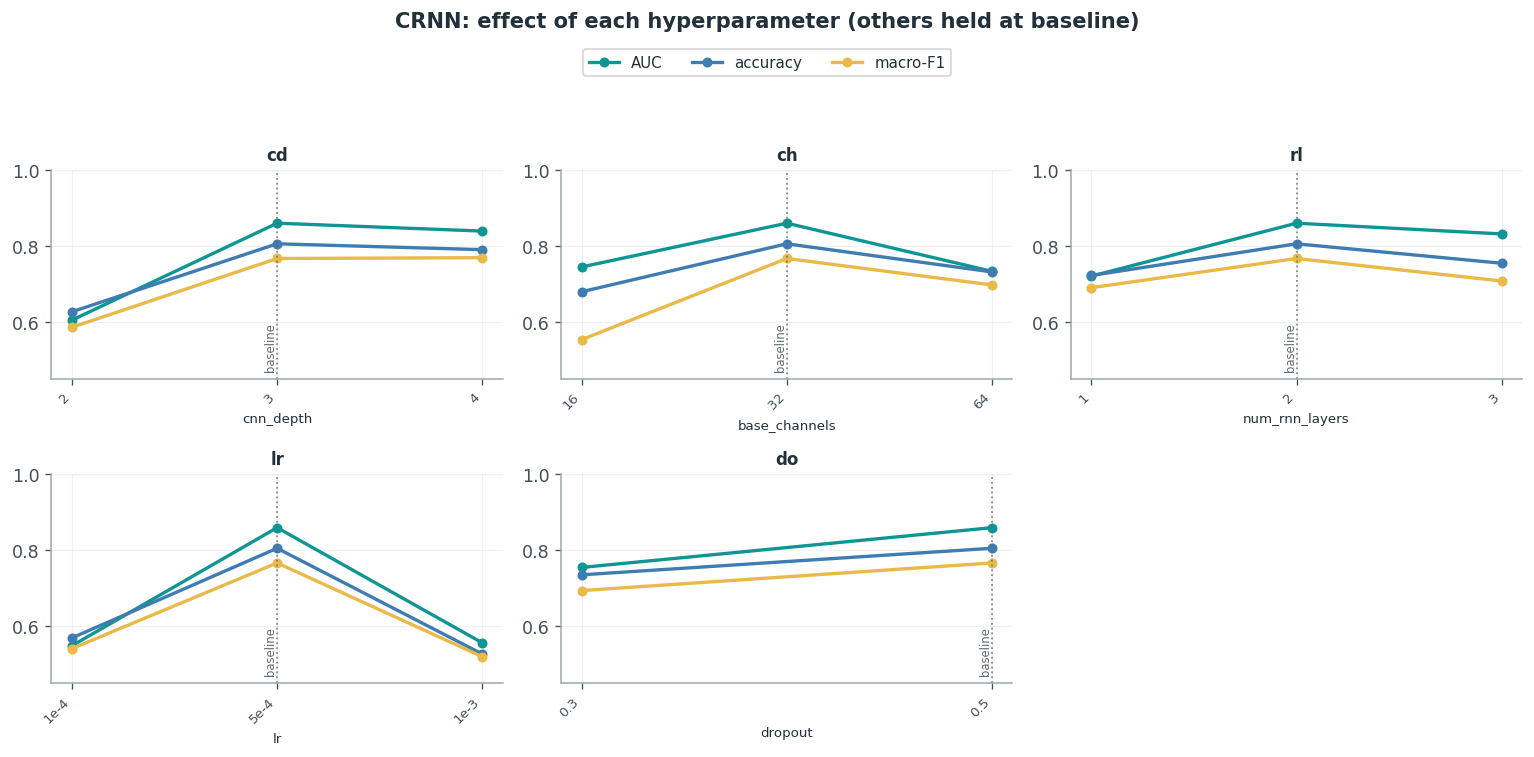

In [11]:
plot_hparam_effects("CRNN", "crnn_experiments/crnn")

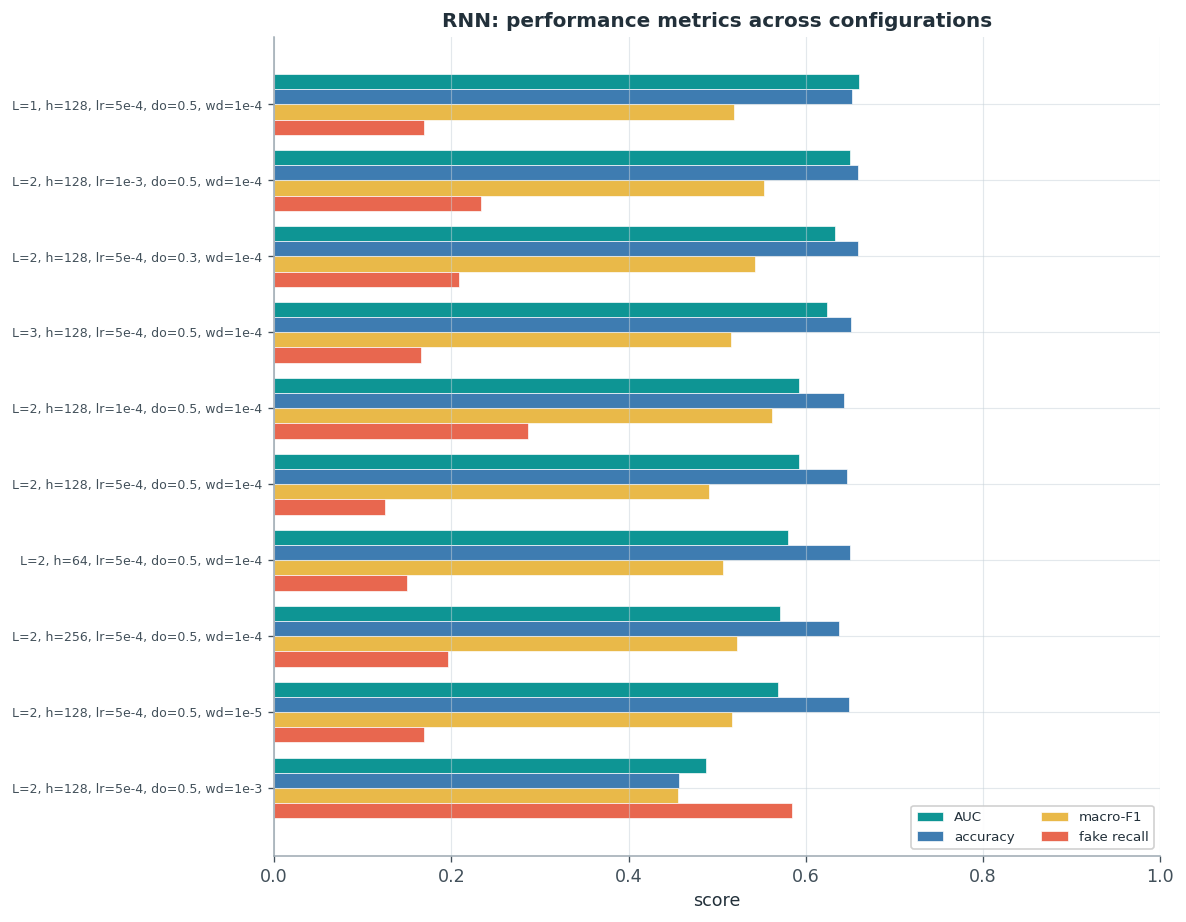

In [12]:
plot_family("RNN", "rnn_experiments/rnn")

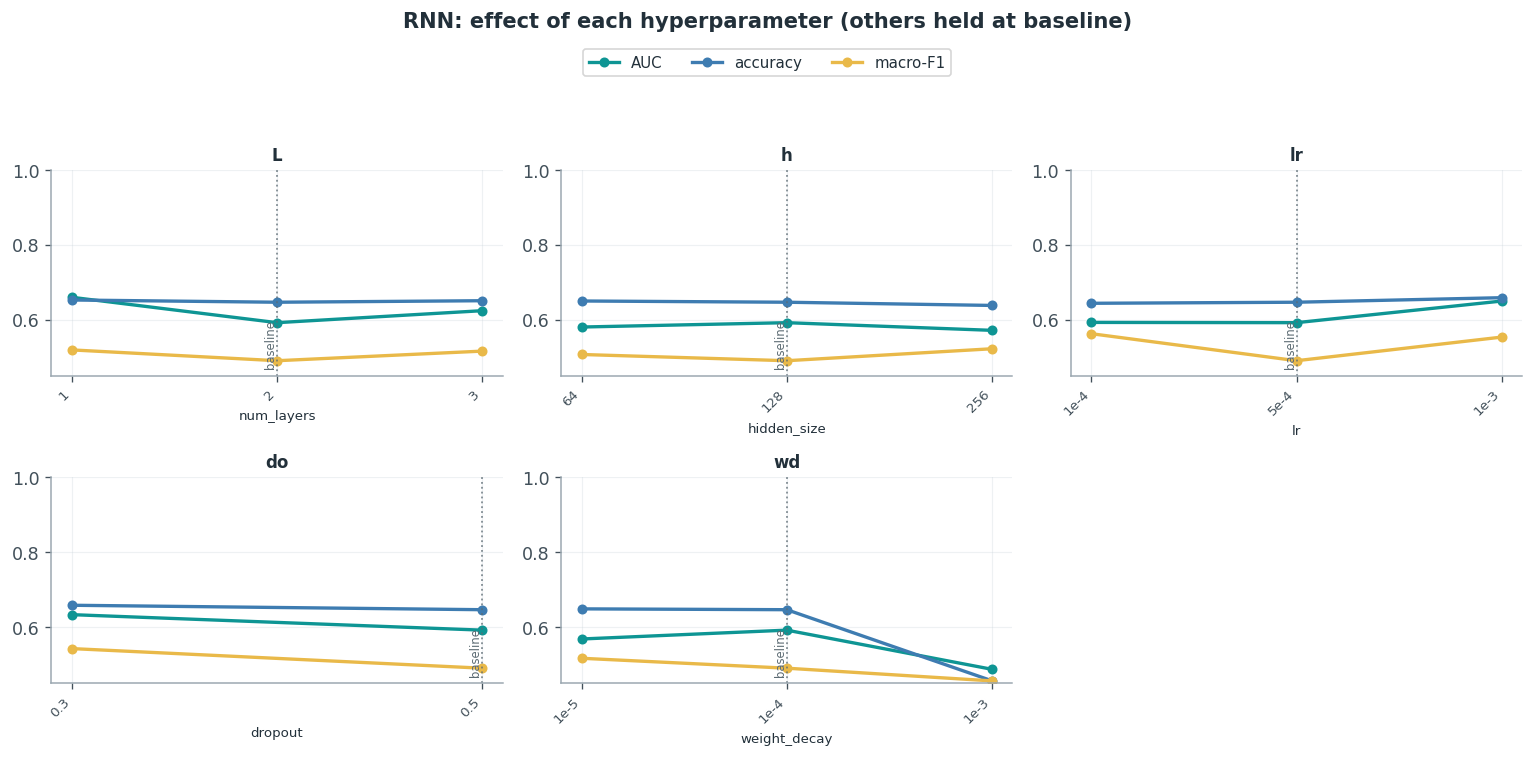

In [13]:
plot_hparam_effects("RNN", "rnn_experiments/rnn")

**Interpretation - the CNN block is what matters.**

- **CRNN reaches AUC ~ 0.86**, matching the pure CNN, while the **pure RNN tops out at 0.66**, barely above the MLP. Without a convolutional block the BiLSTM must learn both *what* the local patterns are and *how* they evolve, and does the first poorly.
- **Pure RNN** gains nothing from more layers / wider hidden - bottlenecked by representation, not temporal capacity.

**Takeaway:** Combining RNN and CNN architectures doesn't lead to better performance than standalone CNN models.

## 8. Architecture 4 - WavLM (self-supervised backbone)
`microsoft/wavlm-base-plus` consumes the **raw waveform**. Two usage modes:

- **Frozen backbone** - The network learns a softmax-weighted sum over its 12 or 13 hidden states + a linear or MLP head.
- **Full fine-tune** - The backbone is trainable with many variants of layers kept frozen. Online train-time augmentation (MUSAN noise / RIR reverb) is also applied along with offline codec augmentation.

In [19]:
_pf = list((RESULTS / "wavlm_base_plus").glob("metrics_probe_*.json"))
_primary_files = [p for p in _pf if "cnn_included" not in p.name] or _pf

# Dynamically find the best primary probe based on ITW AUC
primary_probes = []
for p in _primary_files:
    d = json.load(open(p))
    if "itw_test" in d and "auc" in d["itw_test"]:
        primary_probes.append((d["itw_test"]["auc"], p.name, d))

primary_probes.sort(reverse=True)
best_probe_auc, best_probe_name, probe = primary_probes[0]
print(f"Best frozen probe variant by ITW AUC: {best_probe_name} (ITW AUC {best_probe_auc:.4f})")

probe_13L = next((json.load(open(p)) for p in _pf if "cnn_included" in p.name), None)  # 13-layer (CNN-incl) ablation

ft = []
for p in (RESULTS / "wavlm_base_plus_finetune").glob("metrics_*.json"):
    d = json.load(open(p))
    if "itw_test" in d and "auc" in d["itw_test"]:
        ft.append((d["itw_test"]["auc"], p.name, d))
ft.sort(reverse=True)
best_ft_auc, best_ft_name, best_ft = ft[0]
print(f"Best fine-tune variant by ITW AUC: {best_ft_name}  (ITW AUC {best_ft_auc:.4f})")

def wl_row(name, d):
    v, t = d["for_val"], d["itw_test"]
    return {"variant": name, "FoR_AUC": v["auc"], "FoR_acc": v["acc"],
            "ITW_AUC": t["auc"], "ITW_acc": t["acc"],
            "ITW_fake_recall": t["recall_fake"], "ITW_fake_F1": t["f1_fake"]}

wavlm_df = pd.DataFrame([wl_row("Best frozen backbone model", probe),
                         wl_row("Best fine tuned model", best_ft)])
style_table(wavlm_df)

Best frozen probe variant by ITW AUC: metrics_probe_linear_20260620_170514.json (ITW AUC 0.9177)
Best fine-tune variant by ITW AUC: metrics_finetune_aug_top2_20260623_003954.json  (ITW AUC 0.8654)


,variant,FoR_AUC,FoR_acc,ITW_AUC,ITW_acc,ITW_fake_recall,ITW_fake_F1
0,Best frozen backbone model,0.982576,0.920371,0.917671,0.814657,0.573714,0.697141
1,Best fine tuned model,0.994767,0.954467,0.865355,0.749300,0.453114,0.573387


### 8.1 Frozen backbone experiments

With the backbone frozen, we compare lightweight probe configurations that vary the classifier head (a single linear layer vs a small MLP), the head learning rate, and whether the CNN-embedding layer is included in the weighted sum (12 vs 13 layers). Only the per-layer softmax weights and the head are trained.

In [25]:
import glob
import json
import os
import pandas as pd

probe_rows = []
for f in sorted(glob.glob(str(RESULTS / "wavlm_base_plus" / "metrics_probe_*.json"))):
    d = json.load(open(f))
    
    name = os.path.basename(f)
    
    lw = d.get("layer_weights_softmax") or []
    head = "MLP" if "mlp" in name else "linear"
    
    # Safely extract the learning rate
    config = d.get("config", {})
    if isinstance(config, dict):
        lr = config.get("training", {}).get("lr", "unknown")
    else:
        lr = "1e-2" if "lr1e-2" in name else "1e-3"
    
    t, v = d.get("itw_test", {}), d.get("for_val", {})
    
    probe_rows.append({
        "variant": name,
        "head": head, 
        "lr": lr, 
        "layers": len(lw),
        
        # FoR metrics
        "FoR_AUC": v.get("auc"), 
        "FoR_acc": v.get("acc"),
        "FoR_fake_recall": v.get("recall_fake"),
        
        # ITW metrics
        "ITW_AUC": t.get("auc"),
        "ITW_acc": t.get("acc"), 
        "ITW_fake_recall": t.get("recall_fake")
    })

probe_df = pd.DataFrame(probe_rows).sort_values("ITW_AUC", ascending=False).reset_index(drop=True)
style_table(probe_df)

,variant,head,lr,layers,FoR_AUC,FoR_acc,FoR_fake_recall,ITW_AUC,ITW_acc,ITW_fake_recall
0,metrics_probe_linear_20260620_170514.json,linear,0.001000,12,0.982576,0.920371,0.880169,0.917671,0.814657,0.573714
1,metrics_probe_cnn_included_13L_20260616_213734.json,linear,1e-3,13,0.982085,0.913466,0.863713,0.917085,0.811070,0.568213
2,metrics_probe_linear_lr1e-2_20260623_022555.json,linear,0.010000,12,0.974551,0.914976,0.911392,0.907052,0.807200,0.607397
3,metrics_probe_mlp_20260623_021048.json,MLP,0.001000,12,0.964771,0.830600,0.679325,0.897416,0.738192,0.332515
4,metrics_probe_linear_lr1e-4_20260623_040518.json,linear,0.000100,12,0.941999,0.870306,0.888608,0.869349,0.763649,0.443636
5,metrics_probe_linear_lr1e-5_20260623_040953.json,linear,0.000010,12,0.850560,0.768019,0.851899,0.540335,0.522263,0.458531


- We notice the the MLP head doesn't provide any benefits in terms of performance so we drop it early and continue using the simpler architecture.
- It's also evident that the learning rate plays large role in the general performance of the model in both datasets, undeperforming massively after 1e-4.

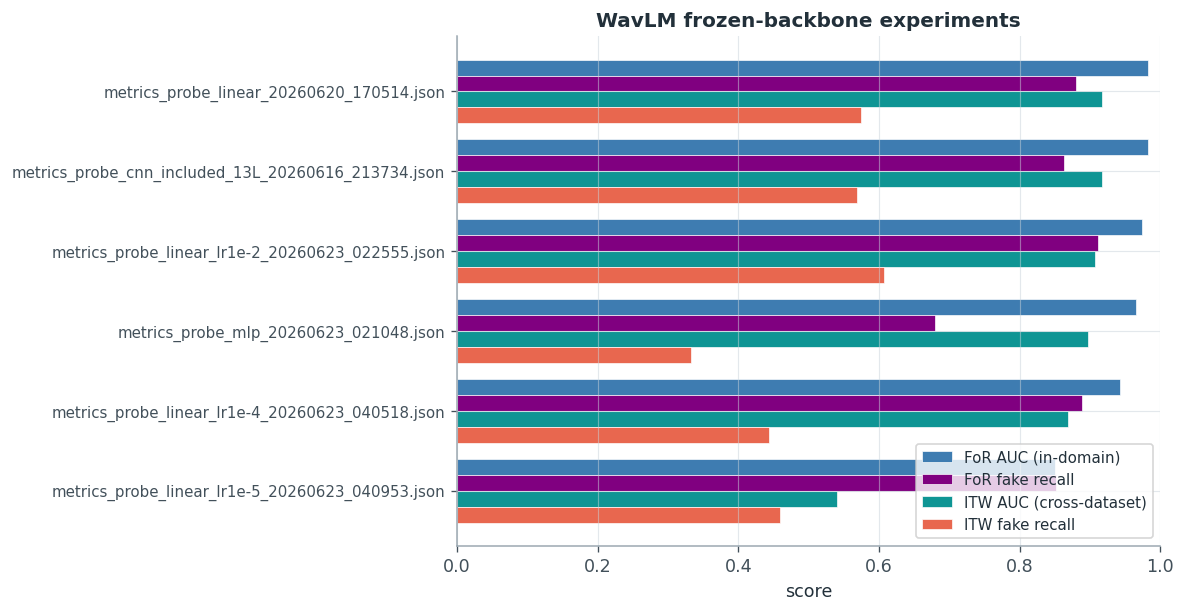

In [28]:
m = probe_df.set_index("variant"); order = m.sort_values("ITW_AUC").index
y = np.arange(len(order)); h = 0.2  # Reduced bar height slightly to fit 4 bars
plt.figure(figsize=(10, 0.62 * len(order) + 1.5))

plt.barh(y + 1.5*h, m.loc[order, "FoR_AUC"],         h, label="FoR AUC (in-domain)",     color=PAL["blue"],  edgecolor="white", linewidth=0.4)
plt.barh(y + 0.5*h, m.loc[order, "FoR_fake_recall"], h, label="FoR fake recall",         color=PAL.get("purple", "purple"),  edgecolor="white", linewidth=0.4)
plt.barh(y - 0.5*h, m.loc[order, "ITW_AUC"],         h, label="ITW AUC (cross-dataset)", color=PAL["teal"],  edgecolor="white", linewidth=0.4)
plt.barh(y - 1.5*h, m.loc[order, "ITW_fake_recall"], h, label="ITW fake recall",         color=PAL["coral"], edgecolor="white", linewidth=0.4)

plt.yticks(y, order, fontsize=9); plt.xlim(0, 1.0); plt.xlabel("score")
plt.title("WavLM frozen-backbone experiments")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()


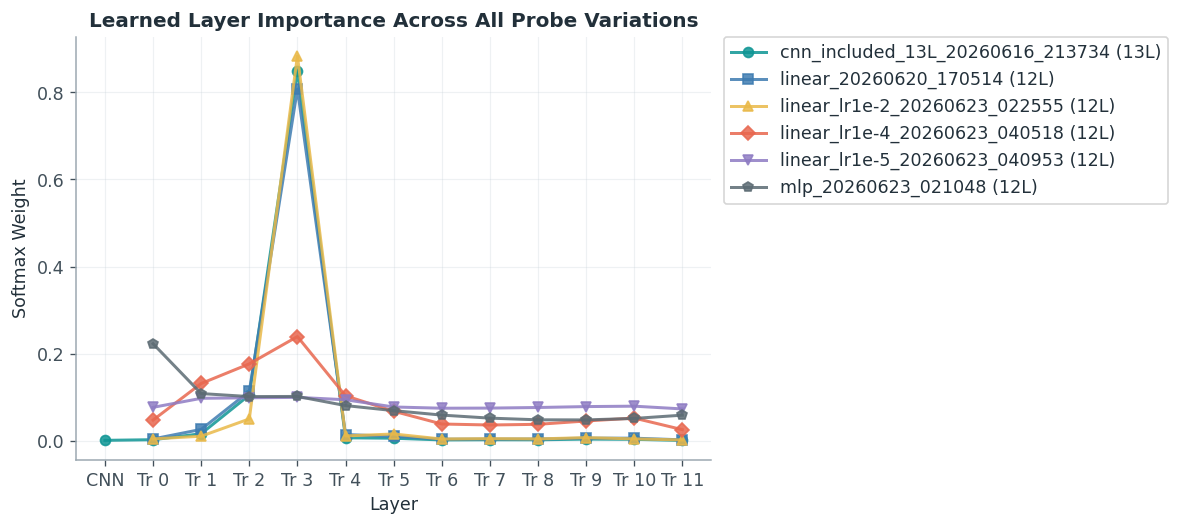

In [31]:
plt.figure(figsize=(10, 4.5))
markers = ['o', 's', '^', 'D', 'v', 'p']
colors_list = [PAL["teal"], PAL["blue"], PAL["amber"], PAL["coral"], PAL["violet"], PAL["slate"]]

all_probes = list((RESULTS / "wavlm_base_plus").glob("metrics_probe_*.json"))

for idx, p in enumerate(sorted(all_probes)):
    d = json.load(open(p))
    w = d.get("layer_weights_softmax")
    if not w:
        continue
    
    # Simplify the file name for the legend
    name = p.stem.replace("metrics_probe_", "")
    
    # Align the layers. 13-layer models have CNN at index 0.
    # 12-layer models start directly with Transformer Block 0.
    if len(w) == 13:
        x = range(0, 13)
        label = f"{name} (13L)"
    else:
        # Shift transformer blocks to x=1..12 to align with the 13L model
        x = range(1, 13)
        label = f"{name} (12L)"
        
    plt.plot(x, w, marker=markers[idx % len(markers)], color=colors_list[idx % len(colors_list)], 
             linewidth=1.8, markersize=6, label=label, alpha=0.85)

# Label x-axis so CNN and Transformer blocks are clearly marked
plt.xticks(range(0, 13), ["CNN"] + [f"Tr {i}" for i in range(12)])
plt.xlabel("Layer")
plt.ylabel("Softmax Weight")
plt.title("Learned Layer Importance Across All Probe Variations")

# Put legend outside the plot so it doesn't overlap the lines
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


- The results above expose a tendency that the performance of the of the pre-trained backbone classifier is largely reliant on the embeddings of the 4th transformer layer.

**Results Interpretation Summary**

**Early-to-mid transformer layers:** Amongst the best performing models we notice that transformer layer 4 embedding accumulates **~81% of the summation weight**, much less to layers 3 and 5 and almost no weight to the rest. This is consistent with the CNN embedding included model as well, so the finding is robust to whether the CNN output is included. We could say that the WavLM mid layers retain acoustic details where synthesis artifacts (unnatural phase, spectral smoothing, vocoder fingerprints) are most visible. Most importantly, a naive last-layer head would have discarded the most useful signal.

### 8.2 Fine-tuning experiments

Beyond the frozen probe, we ran a sweep of **fine-tuning** configurations, varying (i) how many top transformer layers are trainable, (ii) the augmentation applied to the train split, and (iii) the batch size. The CNN feature encoder is kept frozen except in the two "full-unfreeze" runs. The YAML training configuration can be found in the metrics file of the respective run for more details.

In [34]:
import glob
import json
import os
import re
import pandas as pd

ft_rows = []
for f in sorted(glob.glob(str(RESULTS / "wavlm_base_plus_finetune" / "metrics_*.json"))):
    d = json.load(open(f))
    
    # Safely extract the file name on Windows
    name = os.path.basename(f)
    
    cfg = d.get("config", {})
    ft = cfg.get("finetune", {}) if isinstance(cfg, dict) else {}
    aug = d.get("augmentation")
    
    # trainable layers: prefer config, else parse the run name
    nl = ft.get("n_trainable_layers")
    if nl is None:
        mm = re.search(r"top(\d+)", name)
        nl = int(mm.group(1)) if mm else ("all" if re.search(r"unfro|unfreeze", name) else "all")
        
    # augmentation label
    if not aug or "noaug" in name:
        al = "none"
    else:
        pc = aug.get("aug_p_codec", 0) or 0
        al = "noise+RIR+codec" if (("codec" in name and "nocodec" not in name) or pc > 0) else "noise+RIR"
        
    bs = ft.get("batch_size")
    if bs is None:
        mb = re.search(r"b(\d+)", name); bs = int(mb.group(1)) if mb else 32
        
    t, v = d.get("itw_test", {}), d.get("for_val", {})
    
    ft_rows.append({
        "variant": name, # Uses the full file name here
        "trainable_layers": nl, 
        "augmentation": al, 
        "batch": bs,
        
        # FoR metrics
        "FoR_AUC": v.get("auc"), 
        "FoR_acc": v.get("acc"),
        "FoR_fake_recall": v.get("recall_fake"),
        
        # ITW metrics
        "ITW_AUC": t.get("auc"),
        "ITW_acc": t.get("acc"), 
        "ITW_fake_recall": t.get("recall_fake")
    })

ft_df = pd.DataFrame(ft_rows).sort_values("ITW_AUC", ascending=False).reset_index(drop=True)
style_table(ft_df)


,variant,trainable_layers,augmentation,batch,FoR_AUC,FoR_acc,FoR_fake_recall,ITW_AUC,ITW_acc,ITW_fake_recall
0,metrics_finetune_aug_top2_20260623_003954.json,2,noise+RIR,32,0.994767,0.954467,0.929958,0.865355,0.749300,0.453114
1,metrics_finetune_top2_b32_20260620_160154.json,2,noise+RIR,32,0.994624,0.954251,0.927848,0.864513,0.747412,0.444990
2,metrics_20260616_202138_top4_codec.json,4,noise+RIR+codec,32,0.994939,0.958351,0.940084,0.849960,0.726392,0.388287
3,metrics_finetune_top4_cnndrop_b32_20260617_025436.json,4,noise+RIR,32,0.994665,0.956625,0.935865,0.849148,0.723654,0.382024
4,metrics_finetune_noaug_top2_20260623_034628.json,2,none,32,0.984642,0.930082,0.911814,0.848460,0.740048,0.388541
5,metrics_20260616_170418_top4_nocodec.json,4,noise+RIR,32,0.996066,0.961157,0.937975,0.836417,0.707102,0.346141
6,metrics_finetune_noaug_fullunfreeze_20260622_194411.json,all,none,32,0.824678,0.755287,0.729536,0.828216,0.725133,0.278267
7,metrics_finetune_top4_cnndrop_b64_20260617_014255.json,4,noise+RIR,64,0.989518,0.952093,0.952321,0.774683,0.682432,0.366029
8,metrics_20260616_022830_unfrozen_all.json,all,noise+RIR+codec,32,0.932796,0.861459,0.854008,0.749903,0.702634,0.388372
9,metrics_finetune_top6_codec_20260617_004411.json,6,noise+RIR+codec,32,0.991656,0.960941,0.953165,0.703114,0.631360,0.245176


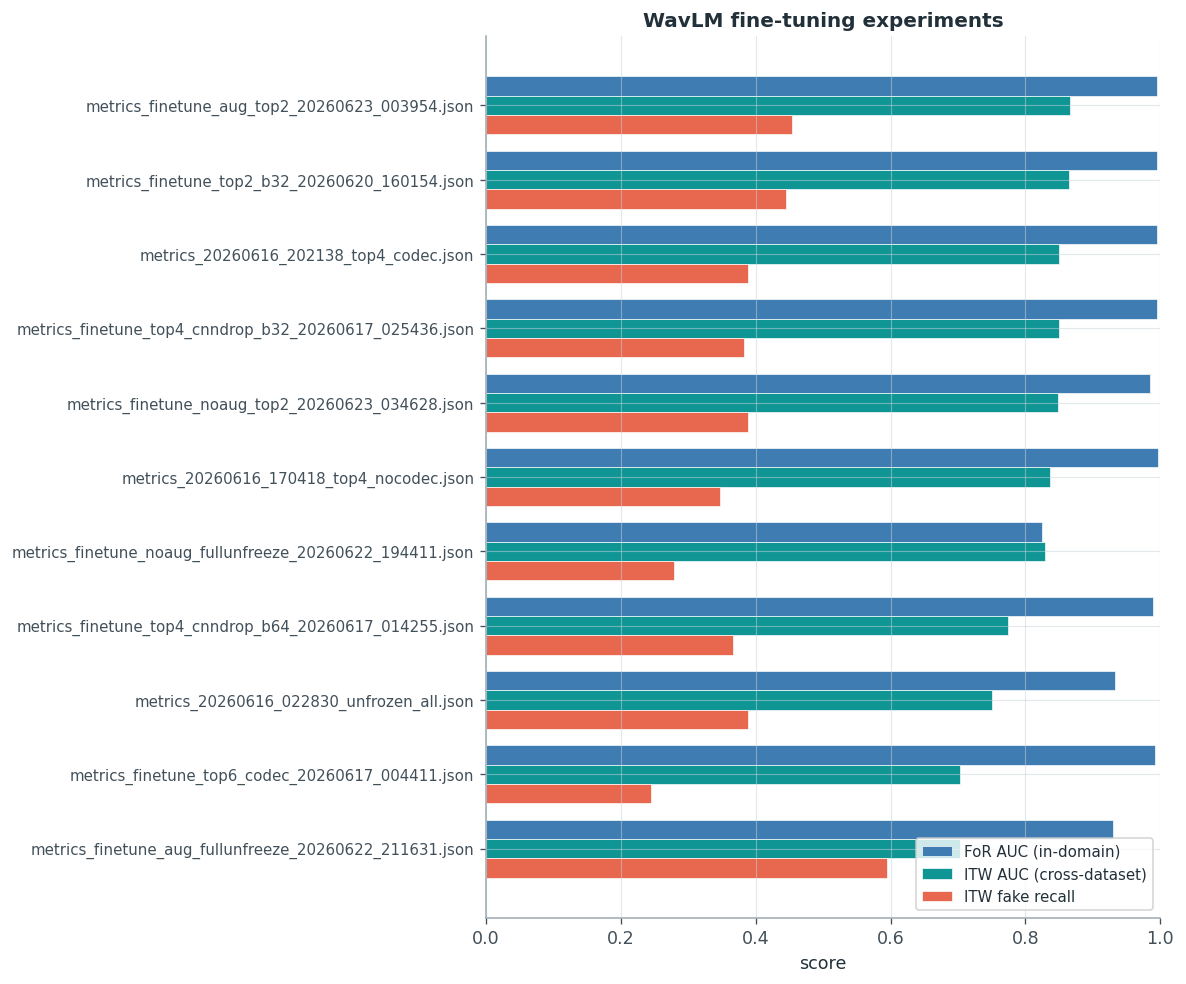

In [36]:
m = ft_df.set_index("variant"); order = m.sort_values("ITW_AUC").index
y = np.arange(len(order)); h = 0.26
plt.figure(figsize=(10, 0.62 * len(order) + 1.5))
plt.barh(y + h, m.loc[order, "FoR_AUC"],         h, label="FoR AUC (in-domain)",     color=PAL["blue"],  edgecolor="white", linewidth=0.4)
plt.barh(y,     m.loc[order, "ITW_AUC"],         h, label="ITW AUC (cross-dataset)", color=PAL["teal"],  edgecolor="white", linewidth=0.4)
plt.barh(y - h, m.loc[order, "ITW_fake_recall"], h, label="ITW fake recall",         color=PAL["coral"], edgecolor="white", linewidth=0.4)
plt.yticks(y, order, fontsize=9); plt.xlim(0, 1.0); plt.xlabel("score")
plt.title("WavLM fine-tuning experiments")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation.**

- **Every fine-tune attempt overfits to the source domain** (FoR AUC up to ~0.99) yet none exceeds **ITW AUC ~0.86**.
- **Fewer trainable layers generalise better.** Unfreezing only the top **2** layers is best (ITW AUC 0.86); going to 4, then 6 layers degrades to 0.85 → 0.70. The less the pretrained backbone is used, the better it transfers.
- **Smaller batch size helps**: the 4-layer run drops from 0.85 (batch 32) to 0.77 (batch 64).
- **Augmentation does not rescue full fine-tuning.** The full-unfreeze run *with* augmentation overfits hardest (FoR 0.93 / ITW 0.75), while the *no-augmentation* full-unfreeze transfers a little better (ITW 0.83). The problem here in the amount of data and their variance not lack of augmentation.
- **Even the best fine-tune (0.86) trails the frozen probe (0.917)** — reinforcing the headline that, under these datasets, minimal perturbation of the pretrained features performs better.


### 8.3 Embedding & score analysis

To see why the cross-dataset gap appears, the runs also saved **UMAP projections** of the pooled embeddings.

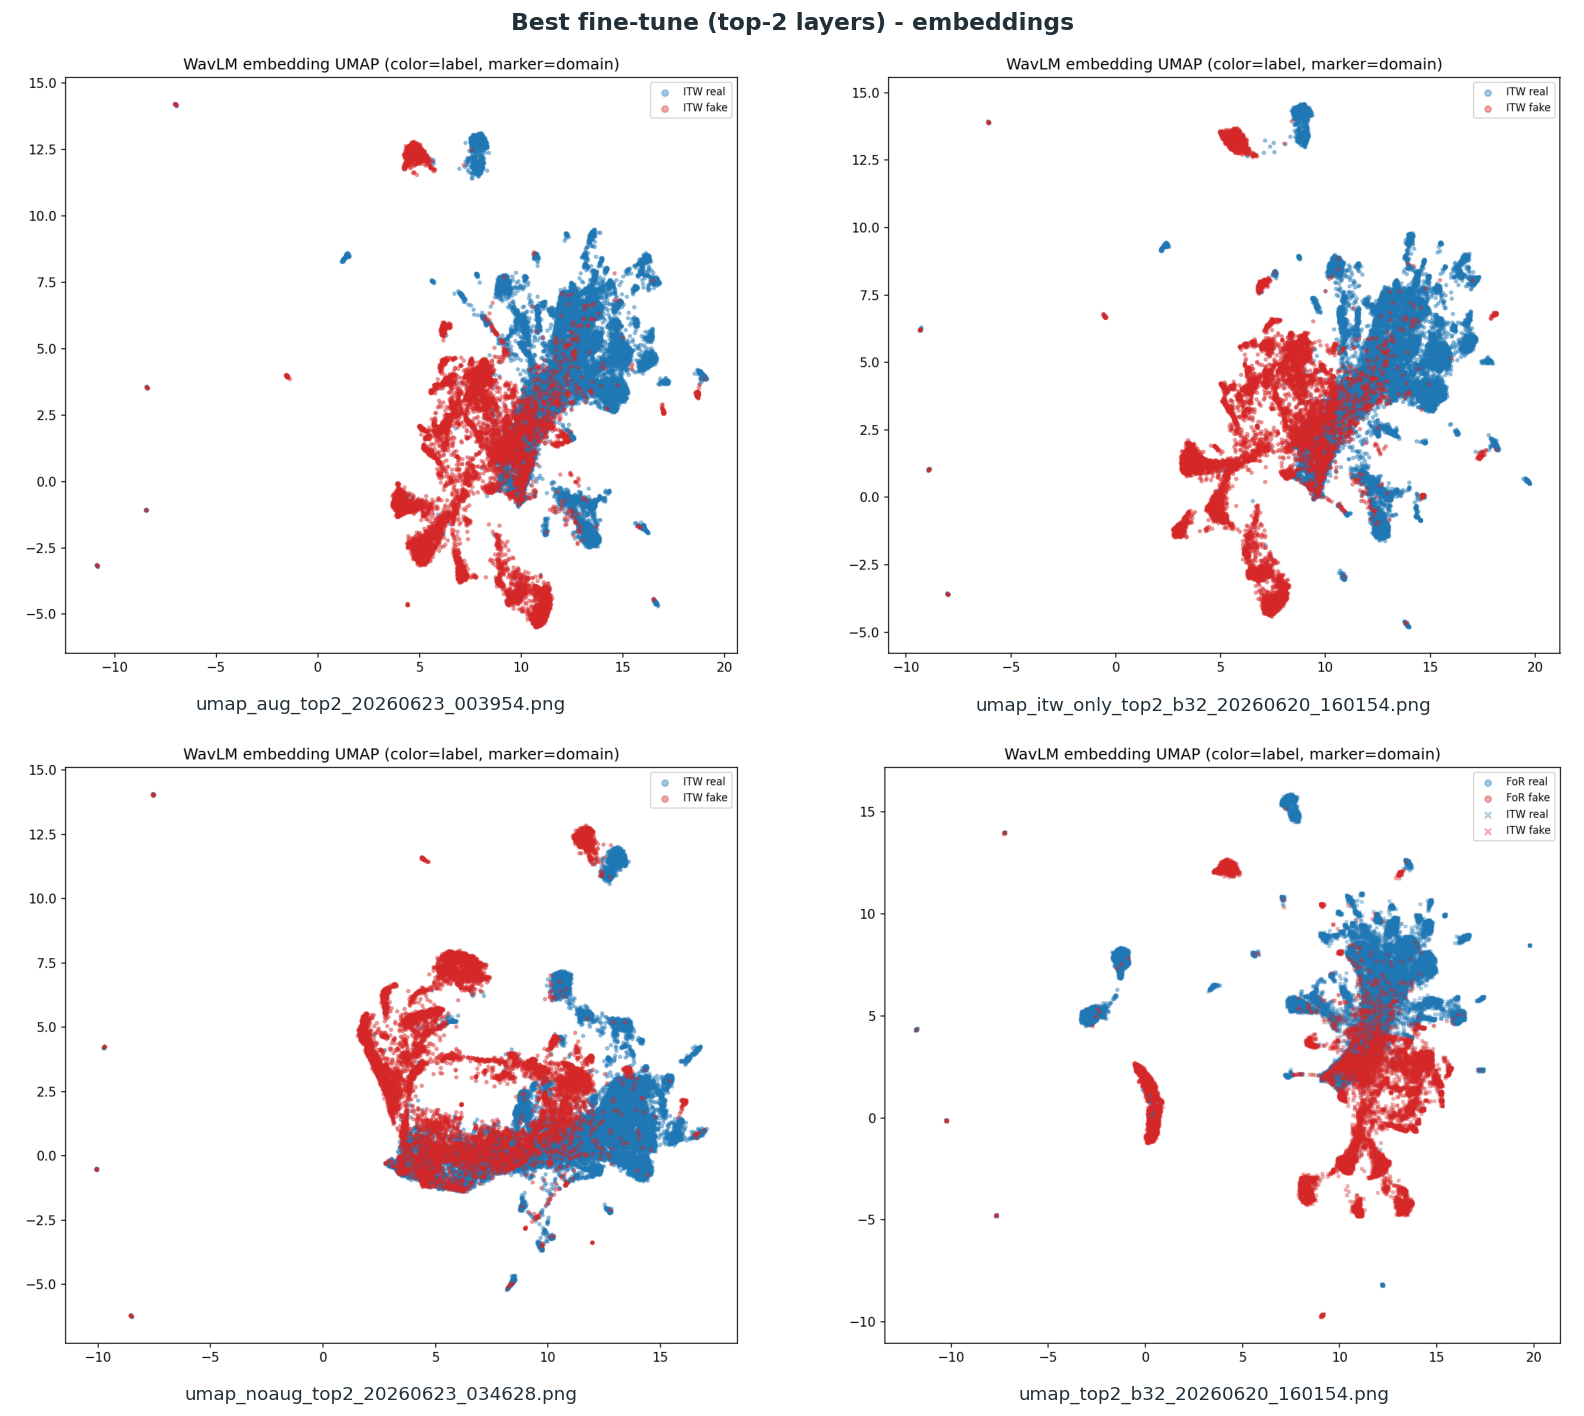

In [48]:
import matplotlib.image as mpimg
import math

ANALYSIS = RESULTS / "wavlm_base_plus_analysis"

def show_imgs(paths, suptitle, cols=2):
    paths = list(paths)
    n = len(paths)
    if not n:
        print("(no images found)")
        return
        
    # Calculate how many rows we need
    rows = math.ceil(n / cols)
    
    # Make the figure size dynamically scale
    fig, axs = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows), squeeze=False)
    
    for i in range(rows):
        for j in range(cols):
            ax = axs[i, j]
            idx = i * cols + j
            
            # If we have an image for this grid slot, show it
            if idx < n:
                p = paths[idx]
                ax.imshow(mpimg.imread(p))
                
                # Place the filename at the bottom using the xlabel
                ax.set_xlabel(p.name, fontsize=11)
                
            # Hide the tick marks and the border frame
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            
    fig.suptitle(suptitle, fontweight="bold", fontsize=14)
    fig.tight_layout()
    plt.show()

# Grab the fine-tune images, filter out histograms, and ONLY keep the 'top2' ones
ft_imgs = sorted(p for p in ANALYSIS.glob("*.png") 
                 if not p.name.startswith("probe_") 
                 and "scorehist" not in p.name 
                 and "top2" in p.name)

# Display just the top-2 fine-tune embeddings in a 2-column grid
show_imgs(ft_imgs, "Best fine-tune (top-2 layers) - embeddings", cols=2)

**Reading the embeddings.** In the UMAP plots for the **ITW** points overlap which explains that we dont achieve good separation of the test data.

## 9. Cross-architecture comparison

In [49]:
def parse_clf_report(txt_path):
    t = Path(txt_path).read_text(); out = {}
    for cls in ("Real", "Fake"):
        m = re.search(cls + r"\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+(\d+)", t)
        out[cls] = tuple(float(x) for x in m.groups()[:3])
    return out

def feat_row(fam, sub):
    top = summ[fam].iloc[0]; tag = top["tag"]
    rep = parse_clf_report(RESULTS / sub / "experiments" / tag / "checkpoints" / ("metrics_" + tag + ".txt"))
    Rp, Rr, Rf = rep["Real"]; Fp, Fr, Ff = rep["Fake"]
    return {"model": fam, "config/mode": tag, "ITW_AUC": top["auc"], "ITW_acc": top["test_acc"],
            "real_P": Rp, "real_R": Rr, "real_F1": Rf, "fake_P": Fp, "fake_R": Fr, "fake_F1": Ff, "macro_F1": (Rf+Ff)/2}

def wl_full(name, d):
    t = d["itw_test"]
    return {"model": name, "config/mode": "wavlm-base-plus", "ITW_AUC": t["auc"], "ITW_acc": t["acc"],
            "real_P": t["precision_real"], "real_R": t["recall_real"], "real_F1": t["f1_real"],
            "fake_P": t["precision_fake"], "fake_R": t["recall_fake"], "fake_F1": t["f1_fake"], "macro_F1": (t["f1_real"]+t["f1_fake"])/2}

rows = [feat_row(f, s) for f, s in FAM.items()]
rows.append(wl_full("WavLM (fine-tune, best)", best_ft))
rows.append(wl_full("WavLM (frozen probe)", probe))
master = pd.DataFrame(rows).sort_values("ITW_AUC", ascending=False).reset_index(drop=True)
master = master[["model","config/mode","ITW_AUC","ITW_acc","macro_F1","real_P","real_R","real_F1","fake_P","fake_R","fake_F1"]]
style_table(master)

,model,config/mode,ITW_AUC,ITW_acc,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,WavLM (frozen probe),wavlm-base-plus,0.917671,0.814657,0.781806,0.791403,0.957271,0.866470,0.888234,0.573714,0.697141
1,CNN,CNN_d3_ch32_lr1e-3_do0.5_wd1e-4,0.870214,0.826584,0.810250,0.841800,0.891400,0.865900,0.796300,0.717000,0.754600
2,"WavLM (fine-tune, best)",wavlm-base-plus,0.865355,0.749300,0.697940,0.740690,0.924611,0.822494,0.780580,0.453114,0.573387
3,CRNN,CRNN_cd3_ch32_rl2_rh128_lr5e-4_do0.5_wd1e-4,0.859611,0.805375,0.766700,0.778300,0.965100,0.861700,0.900800,0.535500,0.671700
4,MLP,NN_h256-128-64_lr1e-3_do0.5_wd1e-4,0.786364,0.683150,0.543600,0.666700,0.987300,0.796000,0.891400,0.174000,0.291200
5,RNN,RNN_l1_h128_lr5e-4_do0.5_wd1e-4,0.659637,0.652443,0.519100,0.656200,0.938400,0.772300,0.619400,0.169300,0.265900


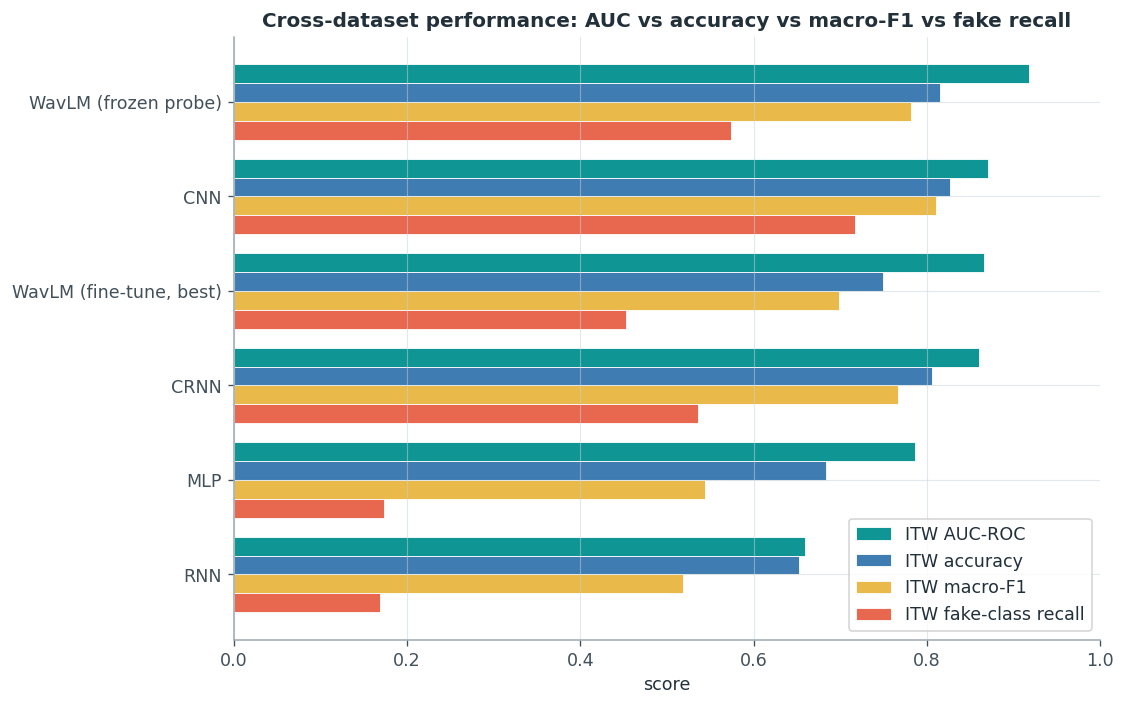

In [50]:
m = master.set_index("model")
order = m.sort_values("ITW_AUC").index
x = np.arange(len(order)); h = 0.2
plt.figure(figsize=(9.5,6))
plt.barh(x+1.5*h, m.loc[order,"ITW_AUC"],  h, label="ITW AUC-ROC",           color=PAL["teal"],  edgecolor="white", linewidth=0.5)
plt.barh(x+0.5*h, m.loc[order,"ITW_acc"],  h, label="ITW accuracy",          color=PAL["blue"],  edgecolor="white", linewidth=0.5)
plt.barh(x-0.5*h, m.loc[order,"macro_F1"], h, label="ITW macro-F1",          color=PAL["amber"], edgecolor="white", linewidth=0.5)
plt.barh(x-1.5*h, m.loc[order,"fake_R"],   h, label="ITW fake-class recall", color=PAL["coral"], edgecolor="white", linewidth=0.5)
plt.yticks(x, order); plt.xlim(0,1.0); plt.xlabel("score")
plt.title("Cross-dataset performance: AUC vs accuracy vs macro-F1 vs fake recall")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Reading the comparison.**

- **AUC:**, the ranking is clean: **WavLM probe (0.92) > CNN (0.87) ~ CRNN (0.86) > WavLM fine-tune (0.85) > MLP (0.79) > RNN (0.66)**.
- **Macro-F1:** (the balanced average across both classes), the real-biased models are penalised hard: the MLP and RNN fall well behind because their fake-class F1 is ~0.27-0.29, while the CNN, CRNN and frozen WavLM probe stay strong - macro-F1 exposes the imbalance that plain accuracy hides.
- **Fake recall:** The **CNN catches ~72% of fakes** - the best at its operating point - whereas the **MLP and RNN catch only ~17%**: they ride the 63% "real" majority to a passable accuracy while being nearly useless as detectors. Even the high-AUC WavLM fine-tune flags only ~39% of fakes at its threshold, a direct symptom of the domain shift.
- **Calibration vs modelling**: A high AUC model with low fake-recall at threshold 0.5 has a *calibration* problem, not a modelling failure — lowering the threshold can recover fake-recall without retraining. A low-AUC model (MLP, RNN) cannot be fixed by calibration alone. The CNN and WavLM probe are well-ranked *and* well-calibrated at the default threshold.

### 9.1 Generalisation gap (FoR -> ITW)

,model,FoR_val_acc,ITW_acc,drop
0,CNN,0.7359,0.8266,-0.0907
1,MLP,0.6770,0.6832,-0.0062
2,CRNN,0.8343,0.8054,0.0289
3,WavLM probe,0.9204,0.8147,0.1057
4,WavLM fine-tune,0.9545,0.7493,0.2052
5,RNN,0.9530,0.6524,0.3005


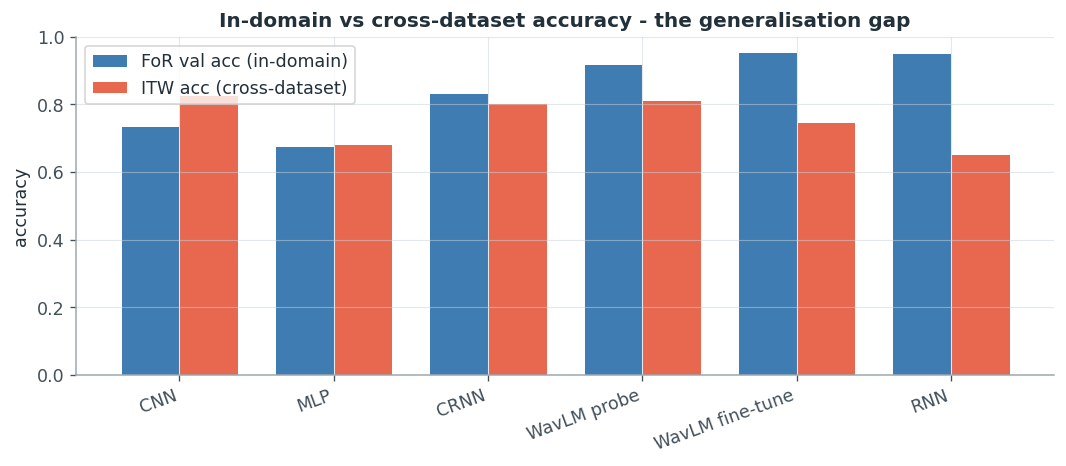

In [51]:
gap_rows = []
for fam, sub in FAM.items():
    top = summ[fam].iloc[0]
    hist = json.load(open(RESULTS / sub / "experiments" / top["tag"] / "checkpoints" / ("history_" + top["tag"] + ".json")))
    for_acc = max(hist["val_acc"])
    gap_rows.append({"model": fam, "FoR_val_acc": for_acc, "ITW_acc": top["test_acc"], "drop": for_acc - top["test_acc"]})
gap_rows.append({"model": "WavLM probe", "FoR_val_acc": probe["for_val"]["acc"], "ITW_acc": probe["itw_test"]["acc"], "drop": probe["for_val"]["acc"] - probe["itw_test"]["acc"]})
gap_rows.append({"model": "WavLM fine-tune", "FoR_val_acc": best_ft["for_val"]["acc"], "ITW_acc": best_ft["itw_test"]["acc"], "drop": best_ft["for_val"]["acc"] - best_ft["itw_test"]["acc"]})
gap = pd.DataFrame(gap_rows).sort_values("drop").reset_index(drop=True)
display(gap)

g = gap.set_index("model"); x = np.arange(len(g)); h = 0.38
plt.figure(figsize=(9,4))
plt.bar(x-h/2, g["FoR_val_acc"], h, label="FoR val acc (in-domain)", color=PAL["blue"],  edgecolor="white", linewidth=0.6)
plt.bar(x+h/2, g["ITW_acc"], h, label="ITW acc (cross-dataset)", color=PAL["coral"], edgecolor="white", linewidth=0.6)
plt.xticks(x, g.index, rotation=20, ha="right"); plt.ylim(0,1.0); plt.ylabel("accuracy")
plt.title("In-domain vs cross-dataset accuracy - the generalisation gap")
plt.legend(); plt.tight_layout(); plt.show()

**Interpretation.** The **fine-tuned WavLM shows the widest gap** - near-perfect FoR accuracy crashing on ITW - confirming source-domain overfitting. The **frozen probe transfers best** (small gap, highest ITW). Among from-scratch models the CNN/CRNN gap is moderate, while the MLP/RNN gap is partly masked because they are weak in both domains.

### 9.2 Training dynamics

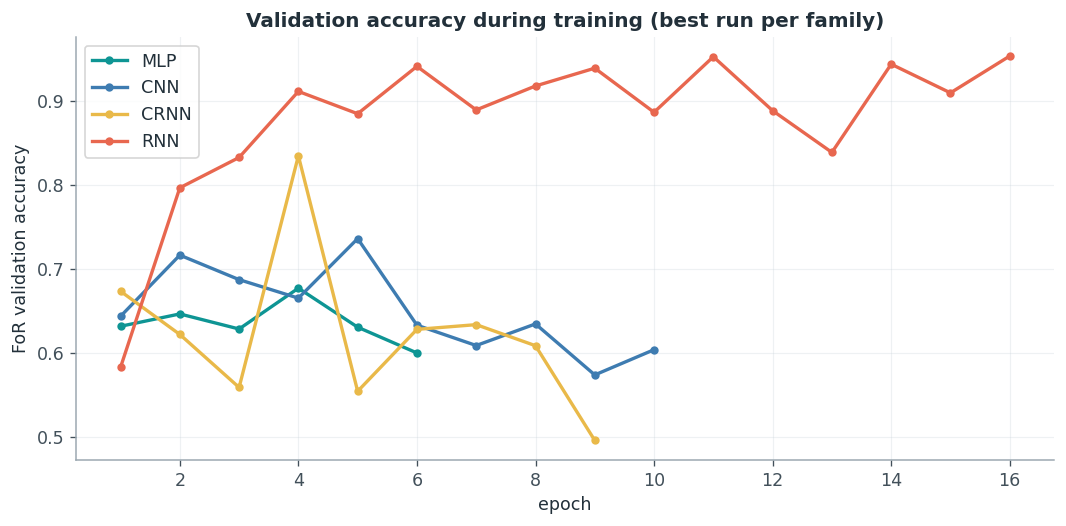

In [52]:
cyc = [PAL["teal"], PAL["blue"], PAL["amber"], PAL["coral"]]
plt.figure(figsize=(9,4.5))
for (fam, sub), col in zip(FAM.items(), cyc):
    top = summ[fam].iloc[0]
    hist = json.load(open(RESULTS / sub / "experiments" / top["tag"] / "checkpoints" / ("history_" + top["tag"] + ".json")))
    plt.plot(range(1, len(hist["val_acc"])+1), hist["val_acc"], marker="o", ms=4, lw=2, color=col, label=fam)
plt.xlabel("epoch"); plt.ylabel("FoR validation accuracy")
plt.title("Validation accuracy during training (best run per family)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

In [53]:
# ─── Architecture pipeline summary table ──────────────────────────────
arch_rows = [
    ("MLP",
     "390-d feature vector\n(MFCC-20, chroma, spectral contrast, ZCR)",
     "Linear → BN → ReLU → Dropout × N",
     "~90K",
     "Hand-crafted features; classifier only"),
    ("CNN",
     "128×T log mel-spectrogram",
     "Conv2d(3×3) → AvgPool → Dropout × depth;\nAdaptiveAvgPool2d → Linear(256→1)",
     "~200K",
     "Learned 2-D spectro-temporal filters"),
    ("CRNN",
     "128×T log mel-spectrogram",
     "CNN blocks → flatten freq dim → BiLSTM layers;\nlast LSTM state → Linear(256→1)",
     "~600K",
     "2-D filters + explicit temporal dynamics"),
    ("RNN",
     "128×T log mel-spectrogram",
     "BiLSTM layers (hidden halves each layer);\nlast state → Linear(256→1)",
     "~250K",
     "Temporal dynamics only — no 2-D filters"),
    ("WavLM probe",
     "Raw waveform (16 kHz)",
     "Frozen backbone (12 transformer blocks + CNN stem);\nsoftmax-weighted layer sum → Linear(hidden→2)",
     "~5K trainable",
     "Self-supervised; probes mid-layer cues"),
    ("WavLM fine-tune",
     "Raw waveform (16 kHz)",
     "Full backbone (unfrozen) + linear head;\nAdamW, low LR, bfloat16 autocast",
     "~94M",
     "Self-supervised; domain-specific fitting"),
]
cols_arch = ["Input", "Core processing", "Params", "Key inductive bias"]
df_arch = pd.DataFrame(arch_rows, columns=["Model"] + cols_arch).set_index("Model")
pd.set_option("display.max_colwidth", 80)
print("Architecture pipeline overview\n")
display(df_arch)

# ─── Ablation grid: hyperparameters varied per family ─────────────────
print("\nAblation grid — one axis at a time, 10 configurations per family\n")
grid_rows = []
for fam in ["MLP", "CNN", "CRNN", "RNN"]:
    d = family_table(fam, FAM[fam])
    baseline = {c: d[c].mode().iloc[0] for c in CONFIG_COLS[fam]}
    for c in CONFIG_COLS[fam]:
        vals = sorted(d[c].unique(), key=_sortkey)
        grid_rows.append({
            "Family": fam,
            "Hyperparameter": _ABBR.get(c, c),
            "Full name": c,
            "Baseline": _fmt(baseline[c]),
            "Values tested": " | ".join(_fmt(v) for v in vals),
            "# levels": d[c].nunique(),
        })
df_grid = pd.DataFrame(grid_rows)
display(df_grid.set_index(["Family", "Hyperparameter"]))

Architecture pipeline overview



,Input,Core processing,Params,Key inductive bias
Model,,,,
MLP,"390-d feature vector\n(MFCC-20, chroma, spectral contrast, ZCR)",Linear → BN → ReLU → Dropout × N,~90K,Hand-crafted features; classifier only
CNN,128×T log mel-spectrogram,Conv2d(3×3) → AvgPool → Dropout × depth;\nAdaptiveAvgPool2d → Linear(256→1),~200K,Learned 2-D spectro-temporal filters
CRNN,128×T log mel-spectrogram,CNN blocks → flatten freq dim → BiLSTM layers;\nlast LSTM state → Linear(256→1),~600K,2-D filters + explicit temporal dynamics
RNN,128×T log mel-spectrogram,BiLSTM layers (hidden halves each layer);\nlast state → Linear(256→1),~250K,Temporal dynamics only — no 2-D filters
WavLM probe,Raw waveform (16 kHz),Frozen backbone (12 transformer blocks + CNN stem);\nsoftmax-weighted layer ...,~5K trainable,Self-supervised; probes mid-layer cues
WavLM fine-tune,Raw waveform (16 kHz),"Full backbone (unfrozen) + linear head;\nAdamW, low LR, bfloat16 autocast",~94M,Self-supervised; domain-specific fitting



Ablation grid — one axis at a time, 10 configurations per family



Full name        Baseline  \
Family Hyperparameter                                   
MLP    h                 hidden_sizes  [256, 128, 64]   
       lr                          lr            5e-4   
       do                     dropout             0.5   
       wd                weight_decay            1e-4   
CNN    depth                    depth               3   
       ch               base_channels              32   
       lr                          lr            5e-4   
       do                     dropout             0.5   
       wd                weight_decay            1e-4   
CRNN   cd                   cnn_depth               3   
       ch               base_channels              32   
       rl              num_rnn_layers               2   
       rh                  rnn_hidden             128   
       lr                          lr            5e-4   
       do                     dropout             0.5   
       wd                weight_decay            1e-4   
RNN    L                   num_layers               2   
       h                  hidden_size             128   
       lr                          lr            5e-4   
       do                     dropout             0.5   
       wd                weight_decay            1e-4   

                                                                                         Values tested  \
Family Hyperparameter                                                                                    
MLP    h               [128] | [256, 128] | [256, 128, 64] | [512, 256, 128] | [256, 128, 64, 32] |...   
       lr                                                                           1e-4 | 5e-4 | 1e-3   
       do                                                                                    0.3 | 0.5   
       wd                                                                                  1e-4 | 1e-3   
CNN    depth                                                                                 2 | 3 | 4   
       ch                                                                                 16 | 32 | 64   
       lr                                                                           1e-4 | 5e-4 | 1e-3   
       do                                                                                    0.3 | 0.5   
       wd                                                                           1e-5 | 1e-4 | 1e-3   
CRNN   cd                                                                                    2 | 3 | 4   
       ch                                                                                 16 | 32 | 64   
       rl                                                                                    1 | 2 | 3   
       rh                                                                                          128   
       lr                                                                           1e-4 | 5e-4 | 1e-3   
       do                                                                                    0.3 | 0.5   
       wd                                                                                         1e-4   
RNN    L                                                                                     1 | 2 | 3   
       h                                                                                64 | 128 | 256   
       lr                                                                           1e-4 | 5e-4 | 1e-3   
       do                                                                                    0.3 | 0.5   
       wd                                                                           1e-5 | 1e-4 | 1e-3   

                       # levels  
Family Hyperparameter            
MLP    h                      6  
       lr                     3  
       do                     2  
       wd                     2  
CNN    depth                  3  
       ch                     3  
     

## 11. Experiment Analysis

The within-family ablations converge on three cross-cutting findings.

### 11.1 Performance ceilings are set by representation, not capacity

The AUC spread *within* each family is far smaller than the gap *between* families. The MLP tops out at ~0.79 regardless of hidden-layer width; the pure RNN at ~0.66 regardless of recurrent capacity. Bigger models within the MLP actually hurt — the widest nets overfit FoR-specific correlations. The bottleneck is the **input representation**, not the classifier: no amount of MLP capacity over hand-crafted features closes the gap to a CNN over spectrograms.

### 11.2 Learning rate is the most impactful hyperparameter

Across all four families, `lr` explains more within-family AUC variance than depth, channels, or regularisation. For the CRNN, AUC collapses from 0.86 to 0.56 when `lr` goes from `5e-4` to `1e-3`; the pure CNN *benefits* from the higher rate. The BiLSTM's recurrent gradients are more sensitive to step size than convolutional filters.

### 11.3 Regularisation must be calibrated, not maximised

Dropout 0.5 > 0.3 across all families. Weight decay is less consistent: `1e-4` helps, `1e-3` is catastrophic for mel-based models (CNN and CRNN AUC near chance). The MLP tolerates stronger L2 because its feature space is fixed and low-dimensional — the penalty only falls on the classifier weights, not on any feature learning.

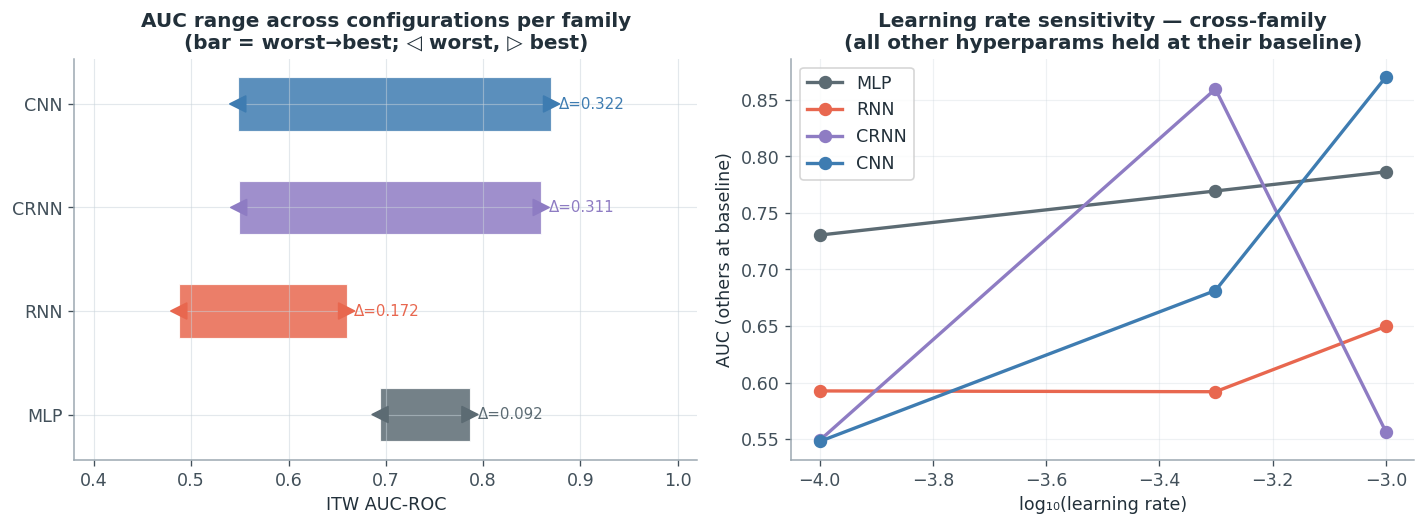

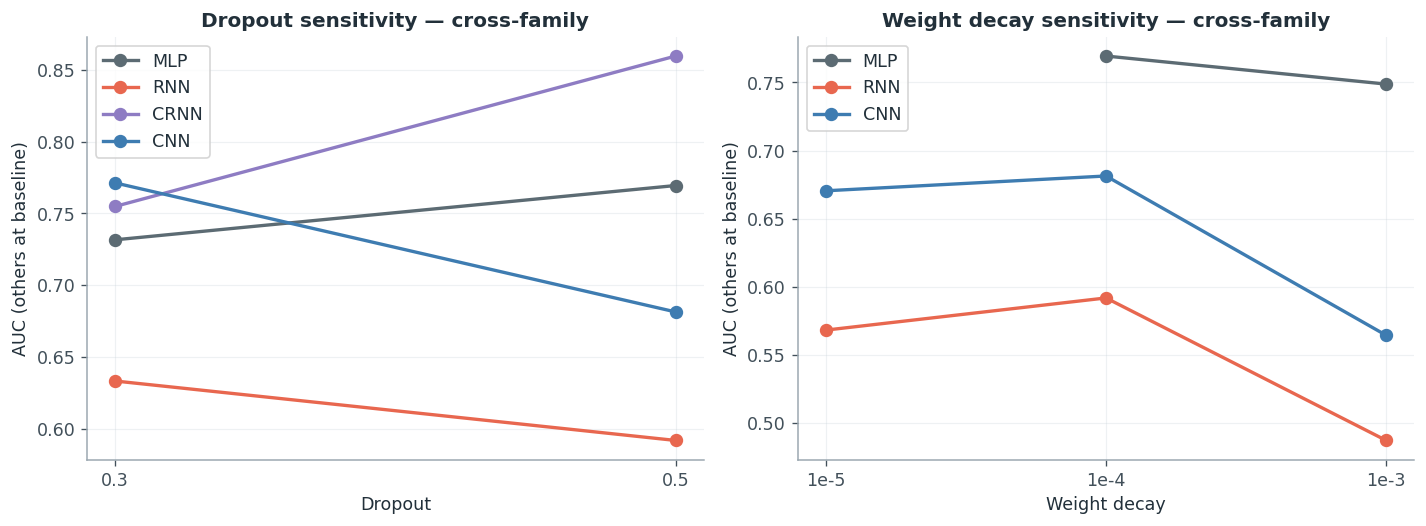

In [42]:
# Cache all family tables once to avoid repeated disk reads
_fam_tables = {fam: family_table(fam, FAM[fam]) for fam in ["MLP", "CNN", "CRNN", "RNN"]}
fam_order = ["MLP", "RNN", "CRNN", "CNN"]   # ascending complexity / ceiling
pal_fam   = [PAL["slate"], PAL["coral"], PAL["violet"], PAL["blue"]]

# ─── AUC range per family: sensitivity to configuration ────────────────
range_data = {fam: {"best": d["AUC"].max(), "worst": d["AUC"].min(),
                    "spread": d["AUC"].max() - d["AUC"].min()}
              for fam, d in _fam_tables.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
x = np.arange(len(fam_order))
bests   = [range_data[f]["best"]   for f in fam_order]
worsts  = [range_data[f]["worst"]  for f in fam_order]
spreads = [range_data[f]["spread"] for f in fam_order]
ax.barh(x, spreads, left=worsts, height=0.52, color=pal_fam,
        edgecolor="white", lw=0.7, alpha=0.85)
ax.scatter(bests,  x, zorder=5, color=pal_fam, s=90, marker=">")
ax.scatter(worsts, x, zorder=5, color=pal_fam, s=90, marker="<")
ax.set_yticks(x); ax.set_yticklabels(fam_order)
ax.set_xlabel("ITW AUC-ROC"); ax.set_xlim(0.38, 1.02)
ax.set_title("AUC range across configurations per family\n(bar = worst→best; ◁ worst, ▷ best)")
for i, (b, s, col) in enumerate(zip(bests, spreads, pal_fam)):
    ax.text(b + 0.008, i, f"Δ={s:.3f}", va="center", fontsize=9, color=col)

# ─── LR sensitivity: cross-family on the same axes ──────────────────
ax = axes[1]
for fam, col in zip(fam_order, pal_fam):
    d = _fam_tables[fam]
    others = [c for c in CONFIG_COLS[fam] if c != "lr"]
    base = {c: d[c].mode().iloc[0] for c in others}
    mask = (d[others] == pd.Series(base)).all(axis=1) if others else pd.Series([True]*len(d))
    sd = d[mask].copy()
    if sd["lr"].nunique() < 2:
        continue
    sd = sd.assign(_sk=sd["lr"].map(_sortkey)).sort_values("_sk")
    xvals = np.log10(sd["lr"].astype(float))
    ax.plot(xvals, sd["AUC"], marker="o", ms=7, lw=2, color=col, label=fam)

ax.set_xlabel("log₁₀(learning rate)")
ax.set_ylabel("AUC (others at baseline)")
ax.set_title("Learning rate sensitivity — cross-family\n(all other hyperparams held at their baseline)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ─── Regularisation: dropout and weight_decay ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (param, label) in zip(axes, [("dropout", "Dropout"),
                                      ("weight_decay", "Weight decay")]):
    # global x-axis: union of all values tested across families
    all_vals = sorted(
        {v for fam in fam_order if param in CONFIG_COLS[fam]
           for v in _fam_tables[fam][param].unique()},
        key=_sortkey
    )
    val_to_x = {v: i for i, v in enumerate(all_vals)}

    for fam, col in zip(fam_order, pal_fam):
        if param not in CONFIG_COLS[fam]:
            continue
        d = _fam_tables[fam]
        others = [c for c in CONFIG_COLS[fam] if c != param]
        base = {c: d[c].mode().iloc[0] for c in others}
        mask = (d[others] == pd.Series(base)).all(axis=1) if others else pd.Series([True]*len(d))
        sd = d[mask].copy()
        if sd[param].nunique() < 2:
            continue
        sd = sd.assign(_sk=sd[param].map(_sortkey)).sort_values("_sk")
        xpts = [val_to_x.get(v, np.nan) for v in sd[param]]
        ax.plot(xpts, sd["AUC"], marker="o", ms=7, lw=2, color=col, label=fam)

    ax.set_xticks(range(len(all_vals)))
    ax.set_xticklabels([_fmt(v) for v in all_vals])
    ax.set_xlabel(label); ax.set_ylabel("AUC (others at baseline)")
    ax.set_title(f"{label} sensitivity — cross-family")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 12. Results Analysis

### 12.1 AUC vs fake-recall tension

AUC measures **ranking quality** — how often the model scores a fake above a real at any threshold. Fake-class recall measures **operational effectiveness** at a fixed threshold (0.5). They diverge under class imbalance and domain shift.

On ITW (~63% real), cross-entropy training biases the boundary toward "predict real", lifting real-class recall at the cost of fake-class recall. AUC is threshold-free so it's less affected. The consequence is visible in the data: the **WavLM fine-tune reaches ITW AUC 0.865 yet catches only 44.5% of fakes**; the **CNN, with similar AUC 0.870, catches 71.7%**. A high-AUC model with low fake-recall at 0.5 has a **calibration problem**, not a modelling failure — threshold tuning can recover fake-recall without retraining. A low-AUC model cannot be rescued by calibration alone. The CNN's higher fake-recall (71.7% vs WavLM fine-tune's 44.5%) largely reflects better calibration on the shifted domain, not a superior ranking ability.

### 12.2 Error decomposition

Each model's errors fall into two types:
- **False negatives on fakes** (missed detections, `1 − fake_recall`): the primary failure mode. MLP and RNN miss ~83% of fakes — operationally useless despite passable accuracy.
- **False positives on real** (false alarms, `1 − real_recall`): secondary. All models classify real speech reasonably well; the challenge is entirely on the fake side.

The CNN and frozen WavLM probe are the only models where **both error rates fall below 30%**.

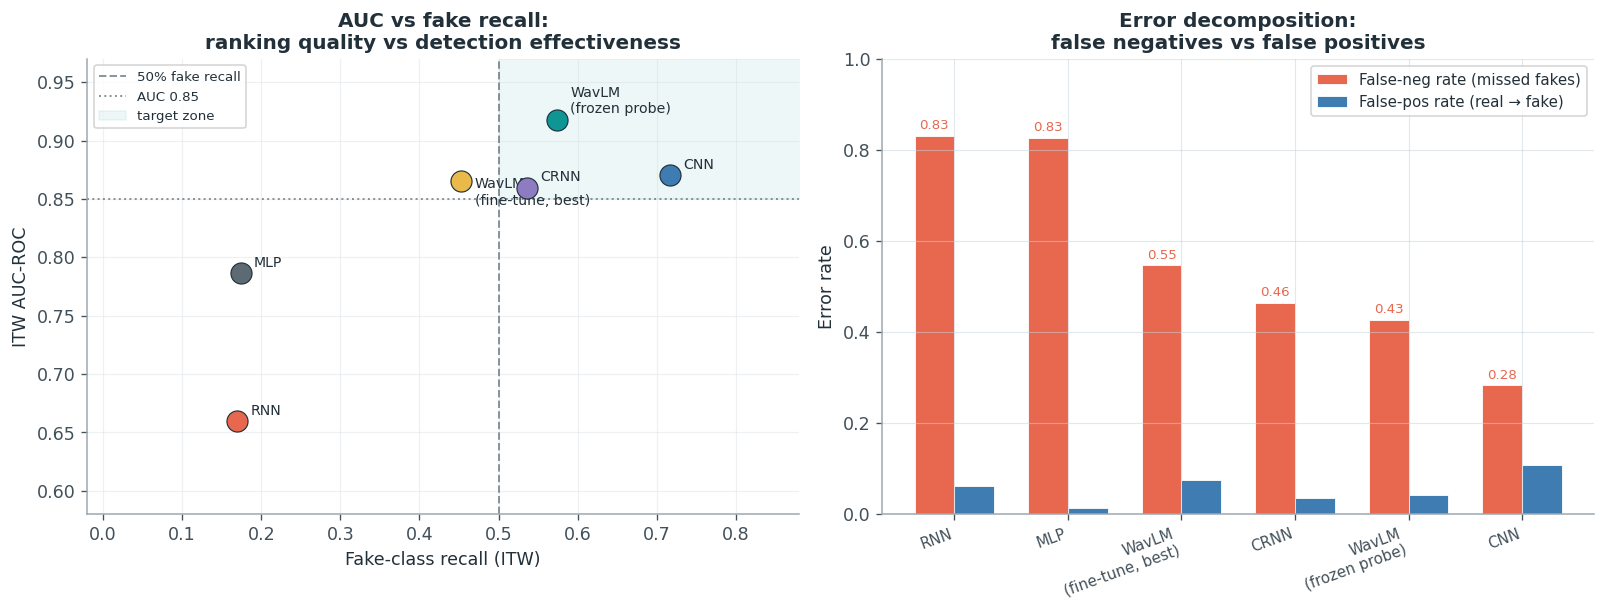

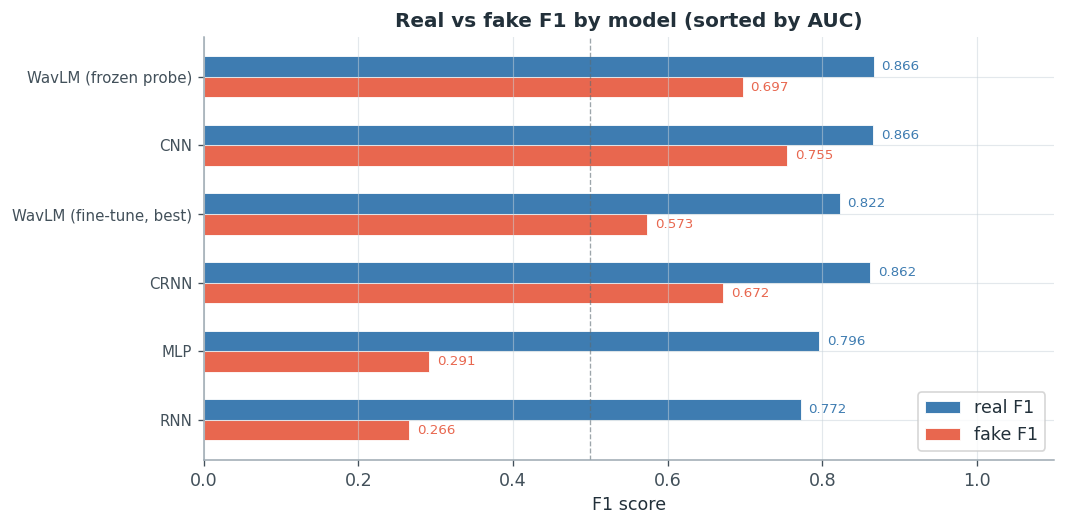

In [54]:
# ─── 1. AUC vs fake-recall scatter ─────────────────────────────────────
pal_map = {"MLP": PAL["slate"], "CNN": PAL["blue"], "CRNN": PAL["violet"],
           "RNN": PAL["coral"], "WavLM (frozen probe)": PAL["teal"],
           "WavLM (fine-tune, best)": PAL["amber"]}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

ax = axes[0]
for _, row in master.iterrows():
    name = row["model"]
    col = pal_map.get(name, PAL["ink"])
    ax.scatter(row["fake_R"], row["ITW_AUC"], s=160, color=col, zorder=5,
               edgecolors=PAL["ink"], linewidths=0.7)
    xytext = (8, 4)
    if name == "WavLM (fine-tune, best)": xytext = (8, -14)
    ax.annotate(name.replace("WavLM ", "WavLM\n"), (row["fake_R"], row["ITW_AUC"]),
                textcoords="offset points", xytext=xytext, fontsize=8.5, color=PAL["ink"])

ax.axvline(0.5, color=PAL["slate"], ls="--", lw=1.2, alpha=0.7, label="50% fake recall")
ax.axhline(0.85, color=PAL["slate"], ls=":", lw=1.2, alpha=0.7, label="AUC 0.85")
ax.fill_between([0.5, 0.9], [0.85, 0.85], [0.97, 0.97], alpha=0.07,
                color=PAL["teal"], label="target zone")
ax.set_xlabel("Fake-class recall (ITW)")
ax.set_ylabel("ITW AUC-ROC")
ax.set_title("AUC vs fake recall:\nranking quality vs detection effectiveness")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 0.88); ax.set_ylim(0.58, 0.97)

# ─── 2. False negative vs false positive rates ─────────────────────────
ax = axes[1]
order_fn = master.sort_values("fake_R")
x = np.arange(len(order_fn)); h = 0.35
fn = 1 - order_fn["fake_R"].values
fp = 1 - order_fn["real_R"].values
bars1 = ax.bar(x - h/2, fn, h, label="False-neg rate (missed fakes)",
               color=PAL["coral"], edgecolor="white", lw=0.5)
bars2 = ax.bar(x + h/2, fp, h, label="False-pos rate (real → fake)",
               color=PAL["blue"], edgecolor="white", lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(order_fn["model"].str.replace("WavLM ", "WavLM\n"),
                   rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Error rate"); ax.set_ylim(0, 1.0)
ax.set_title("Error decomposition:\nfalse negatives vs false positives")
ax.legend(fontsize=9)
for bar, v in zip(bars1, fn):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015,
            f"{v:.2f}", ha="center", fontsize=8, color=PAL["coral"])
plt.tight_layout(); plt.show()

# ─── 3. Real vs fake F1 decomposition ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
order_m = master.sort_values("ITW_AUC", ascending=True)
y = np.arange(len(order_m)); h = 0.3
ax.barh(y + h/2, order_m["real_F1"], h, color=PAL["blue"],  label="real F1",
        edgecolor="white", lw=0.5)
ax.barh(y - h/2, order_m["fake_F1"], h, color=PAL["coral"], label="fake F1",
        edgecolor="white", lw=0.5)
ax.set_yticks(y); ax.set_yticklabels(order_m["model"], fontsize=9)
ax.set_xlim(0, 1.1); ax.set_xlabel("F1 score")
ax.axvline(0.5, color=PAL["slate"], ls="--", lw=0.8, alpha=0.6)
ax.set_title("Real vs fake F1 by model (sorted by AUC)")
ax.legend(loc="lower right")
for i, row in enumerate(order_m.itertuples()):
    ax.text(row.real_F1 + 0.01, i + h/2, f"{row.real_F1:.3f}",
            va="center", fontsize=8, color=PAL["blue"])
    ax.text(row.fake_F1 + 0.01, i - h/2, f"{row.fake_F1:.3f}",
            va="center", fontsize=8, color=PAL["coral"])
plt.tight_layout(); plt.show()

